# Prediksi Produktivitas dan Produksi Padi – Provinsi Lampung
## Machine Learning Berbasis Musim Tanam dan Luas Panen (2019–2024)

**Tugas Mata Kuliah Big Data** | Teknik Informatika – Universitas Lampung – 2026

---

### Ringkasan Perbaikan v3

| Aspek | v2 (Sebelumnya) | v3 (Ini) |
|---|---|---|
| Kabupaten dalam model | **5 dari 15** (bug mapping nama) | **15 kabupaten** ✅ |
| Sampel efektif | **30** (seharusnya 90) | **90 sampel** ✅ |
| Metode evaluasi | LOYOCV (ada temporal leakage) | **Walk-Forward Validation** ✅ |
| Baseline model | Tidak ada | **Naive Mean + Naive Kab Mean** ✅ |
| Interpretasi R² produksi | Tidak dikontekstualisasikan | **Dijelaskan & dikontekstualisasikan** ✅ |

---

**Alur kerja:**
1. Data Loading dan Cleaning  
2. Rekayasa Fitur Berbasis Musim Tanam  
3. Exploratory Data Analysis (EDA)  
4. Pemodelan dengan Walk-Forward Validation  
5. Evaluasi Final dan Visualisasi

---
## Section 0 – Persiapan Lingkungan

In [1]:
!pip install xgboost --quiet

In [2]:
import io, json, copy, warnings, datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from google.colab import files
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings('ignore')

# ── Gaya Visualisasi ─────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi'       : 130,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.grid'        : True,
    'grid.alpha'       : 0.3,
    'grid.linestyle'   : '--',
    'font.size'        : 10,
})
PALETTE_KAB = plt.cm.tab20.colors

# ── Konstanta Waktu ──────────────────────────────────────────────────────────
TAHUN_LIST  = list(range(2018, 2025))   # data BPS tersedia
TAHUN_FITUR = list(range(2019, 2025))   # tahun dengan fitur musiman lengkap

# ── Parameter NASA POWER ─────────────────────────────────────────────────────
NASA_PARAMS = ['ALLSKY_SFC_SW_DWN', 'T2M', 'T2M_MAX', 'T2M_MIN', 'RH2M', 'PRECTOTCORR']
NAMA_PARAMS = {
    'ALLSKY_SFC_SW_DWN': 'Radiasi',
    'T2M'              : 'Suhu Avg',
    'T2M_MAX'          : 'Suhu Max',
    'T2M_MIN'          : 'Suhu Min',
    'RH2M'             : 'Kelembapan',
    'PRECTOTCORR'      : 'Curah Hujan',
}

# ── Kalender Musim Tanam Padi (Lampung) ──────────────────────────────────────
MUSIM = {
    'utama'  : {'label': 'Musim Tanam Utama (Panen Raya)',
                'keterangan': 'Nov T-1, Des T-1, Jan T, Feb T, Mar T',
                'warna': '#2ecc71'},
    'gadu'   : {'label': 'Musim Tanam Gadu (Panen Gadu)',
                'keterangan': 'Apr T, Mei T, Jun T, Jul T',
                'warna': '#f1c40f'},
    'kemarau': {'label': 'Musim Tanam Kemarau (Panen Kecil)',
                'keterangan': 'Agu T, Sep T, Okt T',
                'warna': '#e74c3c'},
}

# ── [FIX v3] Daftar 15 Kabupaten BPS (nama persis sesuai data BPS) ───────────
KABUPATEN_LIST = sorted([
    'Bandar Lampung', 'Lampung Barat',  'Lampung Selatan', 'Lampung Tengah',
    'Lampung Timur',  'Lampung Utara',  'Mesuji',          'Metro',
    'Pesawaran',      'Pesisir Barat',  'Pringsewu',       'Tanggamus',
    'Tulang Bawang',  'Tulang Bawang Barat', 'Way Kanan',
])

# ── [FIX v3] Mapping nama file JSON → nama kabupaten BPS ─────────────────────
# Solusi untuk bug: nama file JSON tidak berspasi (CamelCase), sedangkan
# nama kabupaten di BPS menggunakan spasi. Mapping eksplisit menghindari
# kesalahan rename otomatis yang hanya cocok untuk nama satu kata.
NAMA_FILE_KE_KAB = {
    'BandarLampung'    : 'Bandar Lampung',
    'LampungBarat'     : 'Lampung Barat',
    'LampungSelatan'   : 'Lampung Selatan',
    'LampungTengah'    : 'Lampung Tengah',
    'LampungTimur'     : 'Lampung Timur',
    'LampungUtara'     : 'Lampung Utara',
    'WayKanan'         : 'Way Kanan',
    'TulangBawang'     : 'Tulang Bawang',
    'TulangBawangBarat': 'Tulang Bawang Barat',
    'Pesawaran'        : 'Pesawaran',
    'Pringsewu'        : 'Pringsewu',
    'Mesuji'           : 'Mesuji',
    'Tanggamus'        : 'Tanggamus',
    'PesisirBarat'     : 'Pesisir Barat',
    'Metro'            : 'Metro',
}

print("Lingkungan siap.")
print(f"  Tahun data BPS    : {TAHUN_LIST[0]}–{TAHUN_LIST[-1]}")
print(f"  Tahun fitur model : {TAHUN_FITUR[0]}–{TAHUN_FITUR[-1]}")
print(f"  Kabupaten terdaftar: {len(KABUPATEN_LIST)}")
print(f"  Parameter cuaca   : {', '.join(NASA_PARAMS)}")

Lingkungan siap.
  Tahun data BPS    : 2018–2024
  Tahun fitur model : 2019–2024
  Kabupaten terdaftar: 15
  Parameter cuaca   : ALLSKY_SFC_SW_DWN, T2M, T2M_MAX, T2M_MIN, RH2M, PRECTOTCORR


---
## Section 1 – Data Loading dan Cleaning

### 1.1 Data Produksi Padi dan Luas Panen (BPS)

Sumber: BPS Provinsi Lampung. Format CSV lebar dengan struktur:

| Kolom | Isi |
|---|---|
| Kolom 0 | Nama kabupaten/kota (15 wilayah) |
| Kolom 1–7 | Luas Panen (Ha) 2018–2024 |
| Kolom 8–14 | Produksi (Ton) 2018–2024 |

Dua baris pertama berisi header/sub-header dan dikecualikan secara otomatis.  
Baris "Provinsi Lampung" (total agregat) juga dikecualikan.

In [3]:
# Upload file CSV BPS (PadiTahunan.csv)
uploaded_padi = files.upload()
csv_bytes = list(uploaded_padi.values())[0]
print(f"File diterima: {list(uploaded_padi.keys())[0]} ({len(csv_bytes):,} bytes)")

Saving PadiTahunan.csv to PadiTahunan.csv
File diterima: PadiTahunan.csv (2,443 bytes)


In [4]:
def parse_csv_padi(csv_bytes):
    """
    Membaca CSV BPS format lebar dengan multi-level header.

    Struktur kolom setelah pd.read_csv default:
      col[0]   : nama kabupaten/kota  ('Wilayah')
      col[1:8] : Luas Panen (Ha) 2018–2024
      col[8:15]: Produksi (Ton) 2018–2024

    Baris 0–1 : sub-header dan tahun (NaN di col[0]) → dikecualikan otomatis
    Baris 2–16: 15 kabupaten/kota
    Baris 17  : total Provinsi Lampung → dikecualikan
    """
    df_raw    = pd.read_csv(io.BytesIO(csv_bytes))
    col_kab   = df_raw.columns[0]
    data_cols = df_raw.columns[1:]
    luas_cols = data_cols[:7]    # 7 kolom luas panen 2018–2024
    prod_cols = data_cols[7:]    # 7 kolom produksi  2018–2024

    # Filter: hanya baris kabupaten (exclude NaN dan baris total provinsi)
    mask = (df_raw[col_kab].notna() &
            ~df_raw[col_kab].astype(str).str.startswith('Provinsi'))
    df_kab = df_raw[mask].reset_index(drop=True)

    records = []
    for _, row in df_kab.iterrows():
        kab = str(row[col_kab]).strip()
        for j, tahun in enumerate(TAHUN_LIST):
            try:
                luas = float(row[luas_cols[j]])
                prod = float(row[prod_cols[j]])
            except (ValueError, TypeError):
                luas = np.nan
                prod = np.nan
            records.append({'kabupaten': kab, 'tahun': tahun,
                            'luas_panen_ha': luas, 'produksi_ton': prod})
    return pd.DataFrame(records)

df_produksi_luas = parse_csv_padi(csv_bytes)

print(f"Dataset BPS : {df_produksi_luas.shape[0]} baris x {df_produksi_luas.shape[1]} kolom")
print(f"Kabupaten   : {df_produksi_luas['kabupaten'].nunique()} wilayah")
print(f"Tahun       : {df_produksi_luas['tahun'].min()}–{df_produksi_luas['tahun'].max()}")
print(f"Nilai hilang: {df_produksi_luas.isnull().sum().sum()}")
print()
print(df_produksi_luas.groupby('tahun')[['luas_panen_ha','produksi_ton']]
      .sum().round(0).to_string())

Dataset BPS : 105 baris x 4 kolom
Kabupaten   : 15 wilayah
Tahun       : 2018–2024
Nilai hilang: 0

       luas_panen_ha  produksi_ton
tahun                             
2018        511941.0     2488642.0
2019        464103.0     2164089.0
2020        545149.0     2650290.0
2021        489573.0     2485453.0
2022        518256.0     2688160.0
2023        530108.0     2757898.0
2024        531715.0     2791348.0


### 1.2 Data Cuaca NASA POWER

Sumber: NASA POWER API (parameter harian, 2018–2024).  
Setiap kabupaten diwakili oleh satu koordinat representatif (centroid).

> **[FIX v3]** Nama kabupaten kini dipetakan menggunakan `NAMA_FILE_KE_KAB` —
> kamus eksplisit yang mencocokkan nama file CamelCase (mis. `LampungTengah.json`)
> dengan nama resmi BPS (`Lampung Tengah`). Perbaikan ini memastikan semua
> 15 kabupaten berhasil di-*merge*, bukan hanya 5 kabupaten nama satu kata.

In [5]:
# Upload semua 15 file JSON cuaca sekaligus
uploaded_cuaca = files.upload()
print(f"{len(uploaded_cuaca)} file diterima:")
for fname, data in uploaded_cuaca.items():
    print(f"  {fname} ({len(data):,} bytes)")

Saving PesisirBarat.json to PesisirBarat.json
Saving BandarLampung.json to BandarLampung.json
Saving Metro.json to Metro.json
Saving LampungSelatan.json to LampungSelatan.json
Saving LampungTengah.json to LampungTengah.json
Saving LampungTimur.json to LampungTimur.json
Saving LampungUtara.json to LampungUtara.json
Saving LampungBarat.json to LampungBarat.json
Saving TulangBawang.json to TulangBawang.json
Saving TulangBawangBarat.json to TulangBawangBarat.json
Saving Mesuji.json to Mesuji.json
Saving Tanggamus.json to Tanggamus.json
Saving Pringsewu.json to Pringsewu.json
Saving Pesawaran.json to Pesawaran.json
Saving WayKanan.json to WayKanan.json
15 file diterima:
  PesisirBarat.json (257,626 bytes)
  BandarLampung.json (257,543 bytes)
  Metro.json (256,745 bytes)
  LampungSelatan.json (257,522 bytes)
  LampungTengah.json (256,681 bytes)
  LampungTimur.json (257,450 bytes)
  LampungUtara.json (256,752 bytes)
  LampungBarat.json (257,113 bytes)
  TulangBawang.json (256,817 bytes)
  Tul

In [6]:
def parse_json_nasa(uploaded_dict):
    """
    Membaca satu atau beberapa file JSON NASA POWER.

    [FIX v3] Nama kabupaten diambil dari NAMA_FILE_KE_KAB (mapping eksplisit),
    bukan dari transformasi nama file. Ini memastikan nama kabupaten cocok
    persis dengan nama di data BPS.

    Mengembalikan DataFrame harian:
        kabupaten, tanggal, tahun, bulan, hari, <NASA_PARAMS>
    """
    records = []
    tidak_dikenal = []

    for fname, raw_bytes in uploaded_dict.items():
        # ── [FIX v3] Mapping nama file → nama kabupaten BPS ──────────────────
        fname_key = fname.replace('.json', '').strip()
        kab = NAMA_FILE_KE_KAB.get(fname_key)
        if kab is None:
            tidak_dikenal.append(fname_key)
            print(f"  [SKIP] '{fname_key}' tidak ada di NAMA_FILE_KE_KAB — "
                  f"periksa ejaan nama file.")
            continue

        try:
            payload = json.loads(raw_bytes)
        except json.JSONDecodeError:
            print(f"  [PERINGATAN] Tidak dapat membaca JSON: {fname}")
            continue

        data_params = payload.get('properties', {}).get('parameter', {})
        if not data_params:
            print(f"  [PERINGATAN] Key 'properties.parameter' tidak ditemukan: {fname}")
            continue

        ref_param    = next(iter(data_params))
        tanggal_list = list(data_params[ref_param].keys())

        for tgl in tanggal_list:
            try:
                tgl_dt = pd.to_datetime(tgl, format='%Y%m%d')
            except ValueError:
                continue
            if tgl_dt.year < 2018 or tgl_dt.year > 2024:
                continue

            row = {
                'kabupaten': kab,
                'tanggal'  : tgl_dt,
                'tahun'    : tgl_dt.year,
                'bulan'    : tgl_dt.month,
                'hari'     : tgl_dt.day,
            }
            for p in NASA_PARAMS:
                val = data_params.get(p, {}).get(tgl, np.nan)
                row[p] = np.nan if val in (-999, -99, None) else float(val)
            records.append(row)

    if tidak_dikenal:
        print(f"\n[PERINGATAN] {len(tidak_dikenal)} file tidak dikenal: {tidak_dikenal}")
        print("  → Tambahkan entri ke NAMA_FILE_KE_KAB di Section 0.")

    df = (pd.DataFrame(records)
          .sort_values(['kabupaten', 'tanggal'])
          .reset_index(drop=True))
    return df

df_harian = parse_json_nasa(uploaded_cuaca)

print(f"\nData harian : {df_harian.shape[0]:,} baris")
print(f"Kabupaten   : {df_harian['kabupaten'].nunique()} "
      f"({sorted(df_harian['kabupaten'].unique())})")
print(f"Periode     : {df_harian['tanggal'].min().date()} s.d. "
      f"{df_harian['tanggal'].max().date()}")
print(f"\nNilai hilang per parameter:")
print(df_harian[NASA_PARAMS].isnull().sum().to_string())

# Validasi: pastikan semua 15 kabupaten ter-load
loaded = set(df_harian['kabupaten'].unique())
missing = set(KABUPATEN_LIST) - loaded
if missing:
    print(f"\n[PERINGATAN] {len(missing)} kabupaten belum ter-load: {sorted(missing)}")
    print("  → Upload ulang file JSON untuk kabupaten tersebut.")
else:
    print(f"\n[OK] Semua 15 kabupaten berhasil dimuat.")


Data harian : 38,355 baris
Kabupaten   : 15 (['Bandar Lampung', 'Lampung Barat', 'Lampung Selatan', 'Lampung Tengah', 'Lampung Timur', 'Lampung Utara', 'Mesuji', 'Metro', 'Pesawaran', 'Pesisir Barat', 'Pringsewu', 'Tanggamus', 'Tulang Bawang', 'Tulang Bawang Barat', 'Way Kanan'])
Periode     : 2018-01-01 s.d. 2024-12-31

Nilai hilang per parameter:
ALLSKY_SFC_SW_DWN    0
T2M                  0
T2M_MAX              0
T2M_MIN              0
RH2M                 0
PRECTOTCORR          0

[OK] Semua 15 kabupaten berhasil dimuat.


### 1.3 Penanganan Nilai Hilang

Nilai `-999` (sentinel NASA POWER) sudah dikonversi ke `NaN` pada tahap parsing.  
Imputasi menggunakan median bulanan per kabupaten — lebih robust terhadap outlier
dibanding mean, dan sesuai untuk distribusi cuaca yang bisa condong (skewed).

In [7]:
def imputasi_median_bulanan(df):
    """Imputasi NaN dengan median bulan yang sama per kabupaten."""
    df = df.copy()
    total_nan_awal = df[NASA_PARAMS].isnull().sum().sum()
    if total_nan_awal == 0:
        print("Tidak ada nilai hilang — imputasi dilewati.")
        return df
    for p in NASA_PARAMS:
        if df[p].isnull().sum() == 0:
            continue
        for kab in df['kabupaten'].unique():
            for bln in range(1, 13):
                mask   = (df['kabupaten'] == kab) & (df['bulan'] == bln)
                median = df.loc[mask, p].median()
                df.loc[mask & df[p].isnull(), p] = median
    sisa = df[NASA_PARAMS].isnull().sum().sum()
    print(f"Nilai hilang: {total_nan_awal} → {sisa} setelah imputasi median bulanan.")
    return df

df_harian = imputasi_median_bulanan(df_harian)

Tidak ada nilai hilang — imputasi dilewati.


### 1.4 Agregasi Cuaca ke Level Bulanan

In [8]:
# Curah hujan: SUM (ketersediaan air kumulatif)
# Parameter lain: MEAN (kondisi rata-rata)
AGG_RULES = {p: 'sum' if p == 'PRECTOTCORR' else 'mean' for p in NASA_PARAMS}

df_bulanan = (
    df_harian
    .groupby(['kabupaten', 'tahun', 'bulan'])[NASA_PARAMS]
    .agg(AGG_RULES)
    .reset_index()
)

n_kab      = df_bulanan['kabupaten'].nunique()
n_expected = n_kab * 12 * len(TAHUN_LIST)
print(f"Data bulanan : {df_bulanan.shape[0]} baris  "
      f"({n_kab} kab × 12 bulan × {len(TAHUN_LIST)} tahun)")
print(f"Baris diharapkan: {n_expected} | Selisih: {n_expected - df_bulanan.shape[0]}")

Data bulanan : 1260 baris  (15 kab × 12 bulan × 7 tahun)
Baris diharapkan: 1260 | Selisih: 0


### 1.5 Simpan Dataset Intermediate

In [9]:
df_bulanan.to_csv('cuaca_bulanan_clean.csv', index=False)
df_produksi_luas.to_csv('produksi_luas_clean.csv', index=False)
print("Dataset intermediate disimpan.")
print(f"  cuaca_bulanan_clean.csv  : {df_bulanan.shape}")
print(f"  produksi_luas_clean.csv  : {df_produksi_luas.shape}")

Dataset intermediate disimpan.
  cuaca_bulanan_clean.csv  : (1260, 9)
  produksi_luas_clean.csv  : (105, 4)


---
## Section 2 – Rekayasa Fitur Berbasis Musim Tanam

### 2.1 Desain Fitur Musiman

Fitur cuaca diagregasikan per jendela musim tanam sesuai Kalender Tanam Padi:

| Musim | Jendela Bulan | Keterangan |
|---|---|---|
| Musim Tanam Utama | Nov T-1, Des T-1, Jan T, Feb T, Mar T | Panen Raya – musim penghujan |
| Musim Tanam Gadu | Apr T, Mei T, Jun T, Jul T | Panen Gadu – akhir hujan s.d. awal kemarau |
| Musim Tanam Kemarau | Agu T, Sep T, Okt T | Panen Kecil – irigasi diperlukan |

**Agregasi:**
- `PRECTOTCORR`: **jumlah kumulatif** (mm) – ketersediaan air total per musim  
- Parameter lain: **rata-rata** – kondisi iklim sepanjang musim

**Prospektivitas:** Fitur Musim Utama selesai akhir Maret → prediksi bisa dibuat April.  
Penggunaan ketiga musim memberikan akurasi lebih tinggi, tersedia penuh akhir Oktober.

**Sampel tersedia:** 2019–2024 × 15 kabupaten = **90 sampel**.

In [10]:
def bangun_fitur_musiman(df_bulanan, nasa_params):
    """
    Membangun matriks fitur dari agregasi cuaca per musim tanam.

    Jendela musim (Kalender Tanam Padi Lampung):
      Utama  : Nov T-1, Des T-1, Jan T, Feb T, Mar T  (5 bulan)
      Gadu   : Apr T, Mei T, Jun T, Jul T              (4 bulan)
      Kemarau: Agu T, Sep T, Okt T                     (3 bulan)

    Mengembalikan DataFrame tanpa NaN.
    """
    WINDOWS = {
        'utama'  : lambda t: [(t-1, 11), (t-1, 12), (t, 1), (t, 2), (t, 3)],
        'gadu'   : lambda t: [(t, m) for m in [4, 5, 6, 7]],
        'kemarau': lambda t: [(t, m) for m in [8, 9, 10]],
    }

    def agg_window(df_kab, window, suffix):
        rows = []
        for (y, m) in window:
            r = df_kab[(df_kab['tahun'] == y) & (df_kab['bulan'] == m)]
            if r.empty:
                return None
            rows.append(r[nasa_params].values[0])
        arr   = np.array(rows)
        fitur = {}
        for j, p in enumerate(nasa_params):
            agg   = arr[:, j].sum() if p == 'PRECTOTCORR' else arr[:, j].mean()
            label = 'sum' if p == 'PRECTOTCORR' else 'mean'
            fitur[f'{p}_{suffix}_{label}'] = agg
        return fitur

    records = []
    for kab in sorted(df_bulanan['kabupaten'].unique()):
        df_kab = df_bulanan[df_bulanan['kabupaten'] == kab]
        for tahun in TAHUN_FITUR:
            rec   = {'kabupaten': kab, 'tahun': tahun}
            valid = True
            for musim_name, window_fn in WINDOWS.items():
                f = agg_window(df_kab, window_fn(tahun), musim_name)
                if f is None:
                    valid = False
                    break
                rec.update(f)
            if valid:
                records.append(rec)

    return pd.DataFrame(records)

df_cuaca_fitur = bangun_fitur_musiman(df_bulanan, NASA_PARAMS)
KOLOM_CUACA   = [c for c in df_cuaca_fitur.columns if c not in ['kabupaten', 'tahun']]

print(f"Matriks fitur cuaca: {df_cuaca_fitur.shape[0]} baris × {df_cuaca_fitur.shape[1]} kolom")
print(f"Tahun tersedia     : {sorted(df_cuaca_fitur['tahun'].unique())}")
print(f"Fitur cuaca ({len(KOLOM_CUACA)} kolom):")
for c in KOLOM_CUACA:
    print(f"  {c}")

Matriks fitur cuaca: 90 baris × 20 kolom
Tahun tersedia     : [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Fitur cuaca (18 kolom):
  ALLSKY_SFC_SW_DWN_utama_mean
  T2M_utama_mean
  T2M_MAX_utama_mean
  T2M_MIN_utama_mean
  RH2M_utama_mean
  PRECTOTCORR_utama_sum
  ALLSKY_SFC_SW_DWN_gadu_mean
  T2M_gadu_mean
  T2M_MAX_gadu_mean
  T2M_MIN_gadu_mean
  RH2M_gadu_mean
  PRECTOTCORR_gadu_sum
  ALLSKY_SFC_SW_DWN_kemarau_mean
  T2M_kemarau_mean
  T2M_MAX_kemarau_mean
  T2M_MIN_kemarau_mean
  RH2M_kemarau_mean
  PRECTOTCORR_kemarau_sum


### 2.2 Penggabungan dengan Luas Panen dan Komputasi Target

In [11]:
# Gabungkan fitur cuaca dengan produksi dan luas panen
df_fitur = df_cuaca_fitur.merge(
    df_produksi_luas[['kabupaten', 'tahun', 'luas_panen_ha', 'produksi_ton']],
    on=['kabupaten', 'tahun'],
    how='inner'
)

# Target utama: produktivitas (ton/ha) — menghilangkan efek skala luas lahan
df_fitur['produktivitas_ton_per_ha'] = (
    df_fitur['produksi_ton'] / df_fitur['luas_panen_ha']
)

n_sampel = df_fitur.shape[0]
n_kab    = df_fitur['kabupaten'].nunique()

print(f"Matriks fitur final: {n_sampel} sampel × {df_fitur.shape[1]} kolom")
print(f"  Kabupaten  : {n_kab}  (diharapkan 15)")
print(f"  Tahun      : {sorted(df_fitur['tahun'].unique())}")
print(f"  Fitur cuaca: {len(KOLOM_CUACA)}")
print(f"  Target     : produktivitas_ton_per_ha")
print()

# Validasi sampel
if n_kab < 15:
    print(f"[PERINGATAN] Hanya {n_kab}/15 kabupaten cocok — periksa nama file JSON.")
    kab_missing = set(KABUPATEN_LIST) - set(df_fitur['kabupaten'].unique())
    print(f"  Kabupaten hilang: {sorted(kab_missing)}")
else:
    print("[OK] Semua 15 kabupaten berhasil di-merge.")

print()
print("Statistik target (produktivitas ton/ha):")
desc = df_fitur['produktivitas_ton_per_ha'].describe()
print(desc.round(3).to_string())
cv = desc['std'] / desc['mean'] * 100
print(f"  Koefisien Variasi (CV): {cv:.1f}%  "
      f"← MAPE baseline naif ≈ CV ini")

Matriks fitur final: 90 sampel × 23 kolom
  Kabupaten  : 15  (diharapkan 15)
  Tahun      : [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
  Fitur cuaca: 18
  Target     : produktivitas_ton_per_ha

[OK] Semua 15 kabupaten berhasil di-merge.

Statistik target (produktivitas ton/ha):
count    90.000
mean      5.030
std       0.595
min       3.379
25%       4.631
50%       5.054
75%       5.506
max       6.454
  Koefisien Variasi (CV): 11.8%  ← MAPE baseline naif ≈ CV ini


### 2.3 Persiapan Matriks Model

> **Catatan OHE Kabupaten:** One-Hot Encoding digunakan untuk menangkap efek
> spesifik per kabupaten (kualitas tanah, infrastruktur irigasi, dll.) yang tidak
> tercermin dalam data cuaca. Dengan 15 kabupaten dan `drop_first=True`,
> dihasilkan 14 kolom dummy.  
>
> **Catatan `luas_panen_ha`:** Nilai yang digunakan adalah *luas panen aktual*
> (realisasi BPS), bukan estimasi tanam awal. Dalam prediksi prospektif nyata,
> nilai ini bisa diganti dengan luas tanam yang umumnya tersedia lebih awal.

In [12]:
# One-Hot Encoding kabupaten
df_model = pd.get_dummies(
    df_fitur[KOLOM_CUACA + ['luas_panen_ha', 'kabupaten', 'tahun',
                            'produktivitas_ton_per_ha', 'produksi_ton']],
    columns=['kabupaten'],
    drop_first=True
)

KOLOM_KAB_OHE = [c for c in df_model.columns if c.startswith('kabupaten_')]
FITUR_MODEL   = KOLOM_CUACA + ['luas_panen_ha'] + KOLOM_KAB_OHE

X      = df_model[FITUR_MODEL].values.astype(float)
y      = df_model['produktivitas_ton_per_ha'].values
GROUPS = df_fitur['tahun'].values   # untuk Walk-Forward CV

print(f"Dimensi X      : {X.shape}  (sampel × fitur)")
print(f"Dimensi y      : {y.shape}")
print(f"Jumlah fitur   : {len(FITUR_MODEL)}")
print(f"  Cuaca        : {len(KOLOM_CUACA)}")
print(f"  Luas panen   : 1")
print(f"  Kab OHE      : {len(KOLOM_KAB_OHE)}  (15 kab - 1 referensi)")
print(f"  Total        : {len(FITUR_MODEL)}")
print()
print(f"Rasio sampel/fitur: {X.shape[0]}/{len(FITUR_MODEL)} = "
      f"{X.shape[0]/len(FITUR_MODEL):.1f}:1")
print(f"  (idealnya ≥ 10:1; Ridge & RF diregularisasi untuk rasio rendah)")

Dimensi X      : (90, 33)  (sampel × fitur)
Dimensi y      : (90,)
Jumlah fitur   : 33
  Cuaca        : 18
  Luas panen   : 1
  Kab OHE      : 14  (15 kab - 1 referensi)
  Total        : 33

Rasio sampel/fitur: 90/33 = 2.7:1
  (idealnya ≥ 10:1; Ridge & RF diregularisasi untuk rasio rendah)


---
## Section 3 – Exploratory Data Analysis (EDA)

### 3.1 Statistik Deskriptif per Kabupaten

In [13]:
stat_kab = df_fitur.groupby('kabupaten').agg(
    produksi_mean  =('produksi_ton',            'mean'),
    produksi_std   =('produksi_ton',            'std'),
    luas_mean      =('luas_panen_ha',           'mean'),
    prodvt_mean    =('produktivitas_ton_per_ha', 'mean'),
    prodvt_std     =('produktivitas_ton_per_ha', 'std'),
).round(2).sort_values('produksi_mean', ascending=False)

print("Statistik Produksi, Luas Panen, dan Produktivitas per Kabupaten (2019–2024)")
print("=" * 85)
print(stat_kab.rename(columns={
    'produksi_mean': 'Produksi Rata2 (ton)',
    'produksi_std' : 'Produksi StdDev',
    'luas_mean'    : 'Luas Rata2 (ha)',
    'prodvt_mean'  : 'Produktivitas Rata2 (t/ha)',
    'prodvt_std'   : 'Produktivitas StdDev',
}).to_string())

Statistik Produksi, Luas Panen, dan Produktivitas per Kabupaten (2019–2024)
                     Produksi Rata2 (ton)  Produksi StdDev  Luas Rata2 (ha)  Produktivitas Rata2 (t/ha)  Produktivitas StdDev
kabupaten                                                                                                                    
Lampung Tengah                  555403.42         67264.77        104980.51                        5.28                  0.44
Lampung Timur                   436577.96         50016.59         89707.24                        4.85                  0.27
Lampung Selatan                 310032.93         26680.61         52770.45                        5.89                  0.35
Mesuji                          295691.92         33306.87         61753.90                        4.82                  0.46
Tulang Bawang                   271507.93         64033.65         62153.69                        4.34                  0.38
Tanggamus                       134029.87 

### 3.2 Tren Produktivitas per Kabupaten (2019–2024)

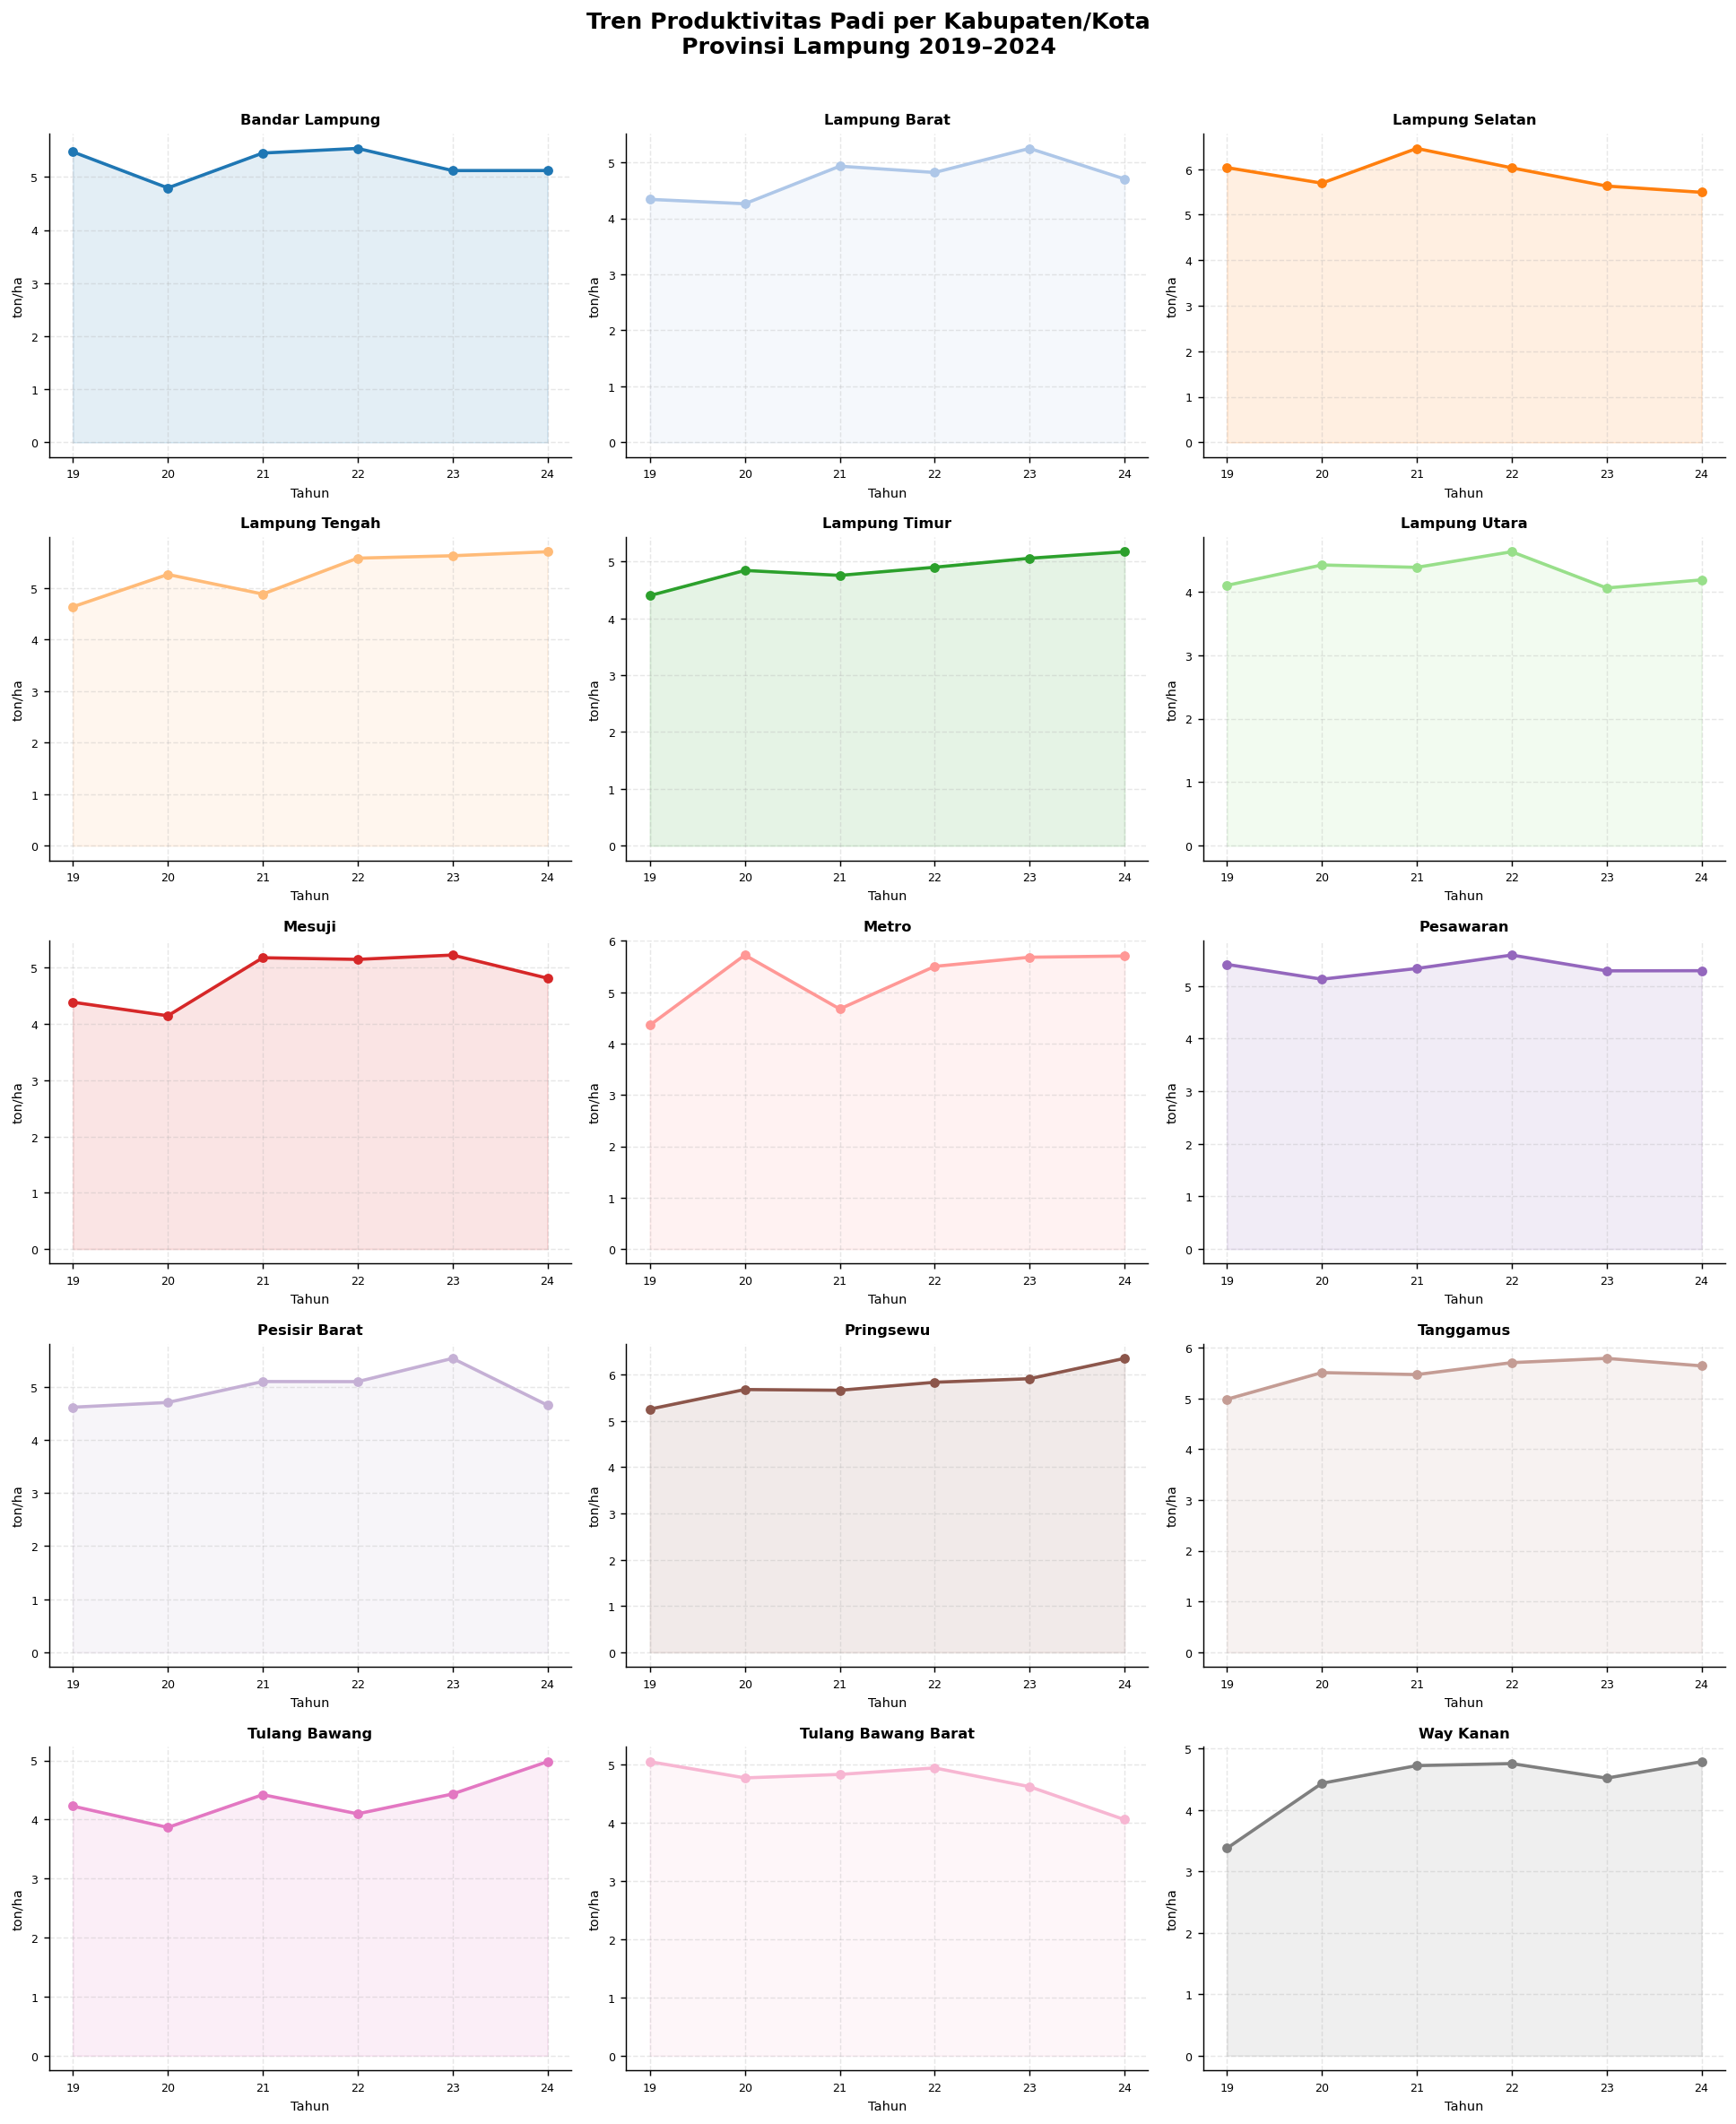

In [14]:
kabupaten_list = sorted(df_fitur['kabupaten'].unique())
n_kab = len(kabupaten_list)
ncols, nrows = 3, 5

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 18))
fig.suptitle('Tren Produktivitas Padi per Kabupaten/Kota\nProvinsi Lampung 2019–2024',
             fontsize=14, fontweight='bold', y=1.01)

for idx, kab in enumerate(kabupaten_list):
    ax    = axes[idx // ncols][idx % ncols]
    df_k  = df_fitur[df_fitur['kabupaten'] == kab].sort_values('tahun')
    color = PALETTE_KAB[idx % len(PALETTE_KAB)]
    ax.plot(df_k['tahun'], df_k['produktivitas_ton_per_ha'],
            marker='o', linewidth=2, markersize=5, color=color)
    ax.fill_between(df_k['tahun'], df_k['produktivitas_ton_per_ha'],
                    alpha=0.12, color=color)
    ax.set_title(kab, fontsize=9, fontweight='bold')
    ax.set_xlabel('Tahun', fontsize=8)
    ax.set_ylabel('ton/ha', fontsize=8)
    ax.set_xticks(TAHUN_FITUR)
    ax.set_xticklabels([str(t)[2:] for t in TAHUN_FITUR], fontsize=7)
    ax.tick_params(axis='y', labelsize=7)

for i in range(n_kab, nrows * ncols):
    axes[i // ncols][i % ncols].set_visible(False)

plt.tight_layout()
plt.savefig('tren_produktivitas.png', bbox_inches='tight', dpi=130)
plt.show()

### 3.3 Distribusi Produktivitas

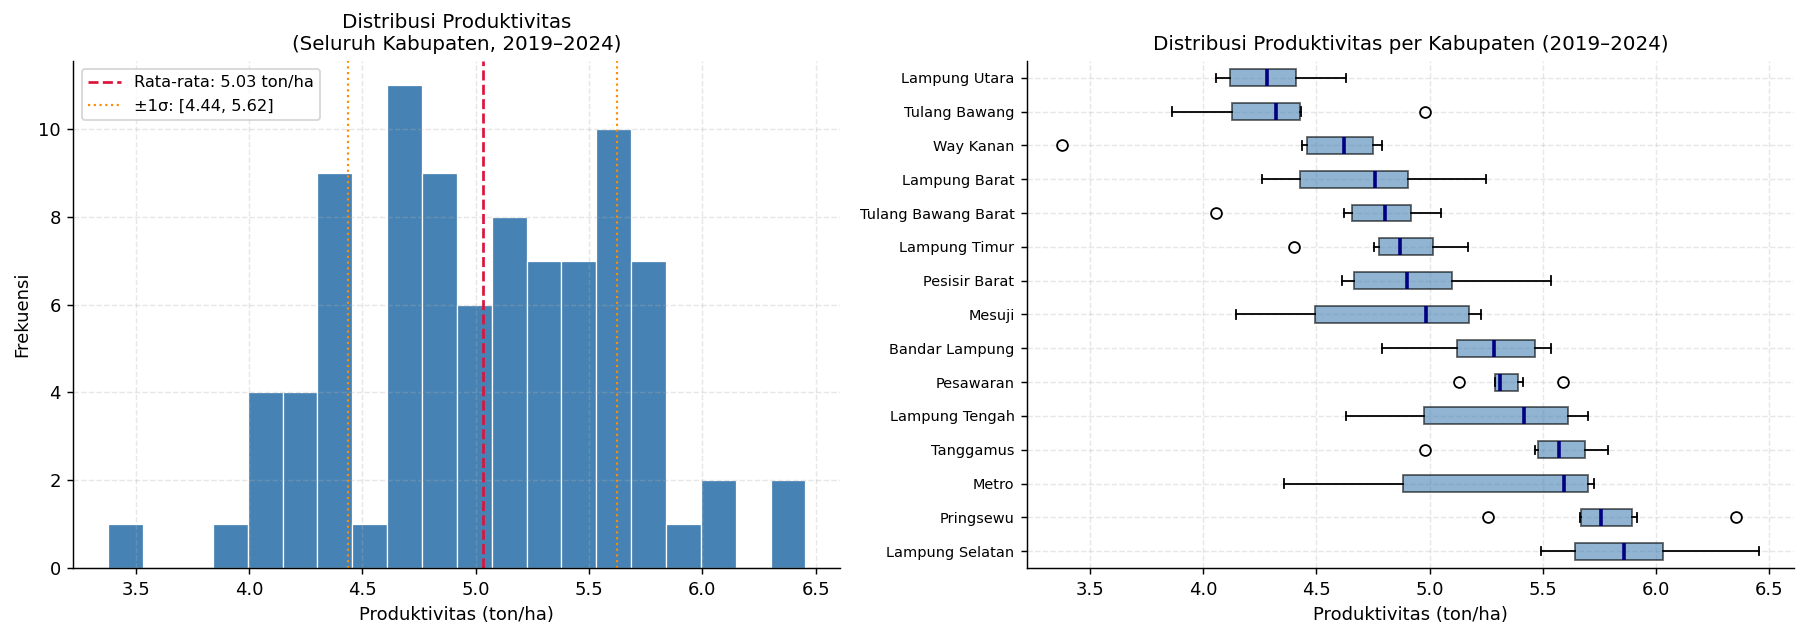

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram seluruh sampel
ax   = axes[0]
vals = df_fitur['produktivitas_ton_per_ha']
ax.hist(vals, bins=20, color='steelblue', edgecolor='white', linewidth=0.7)
ax.axvline(vals.mean(), color='crimson', linestyle='--', linewidth=1.5,
           label=f'Rata-rata: {vals.mean():.2f} ton/ha')
ax.axvline(vals.mean() - vals.std(), color='darkorange', linestyle=':', linewidth=1.2,
           label=f'±1σ: [{vals.mean()-vals.std():.2f}, {vals.mean()+vals.std():.2f}]')
ax.axvline(vals.mean() + vals.std(), color='darkorange', linestyle=':', linewidth=1.2)
ax.set_title('Distribusi Produktivitas\n(Seluruh Kabupaten, 2019–2024)', fontsize=11)
ax.set_xlabel('Produktivitas (ton/ha)')
ax.set_ylabel('Frekuensi')
ax.legend(fontsize=9)

# Boxplot per kabupaten
ax           = axes[1]
median_order = (df_fitur.groupby('kabupaten')['produktivitas_ton_per_ha']
                .median().sort_values(ascending=False).index)
df_box = [df_fitur[df_fitur['kabupaten'] == k]['produktivitas_ton_per_ha'].values
          for k in median_order]
bp = ax.boxplot(df_box, vert=False, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6),
                medianprops=dict(color='navy', linewidth=2))
ax.set_yticks(range(1, len(median_order) + 1))
ax.set_yticklabels(median_order, fontsize=8)
ax.set_title('Distribusi Produktivitas per Kabupaten (2019–2024)', fontsize=11)
ax.set_xlabel('Produktivitas (ton/ha)')

plt.tight_layout()
plt.savefig('distribusi_produktivitas.png', bbox_inches='tight', dpi=130)
plt.show()

### 3.4 Cuaca Musiman Rata-rata per Musim Tanam

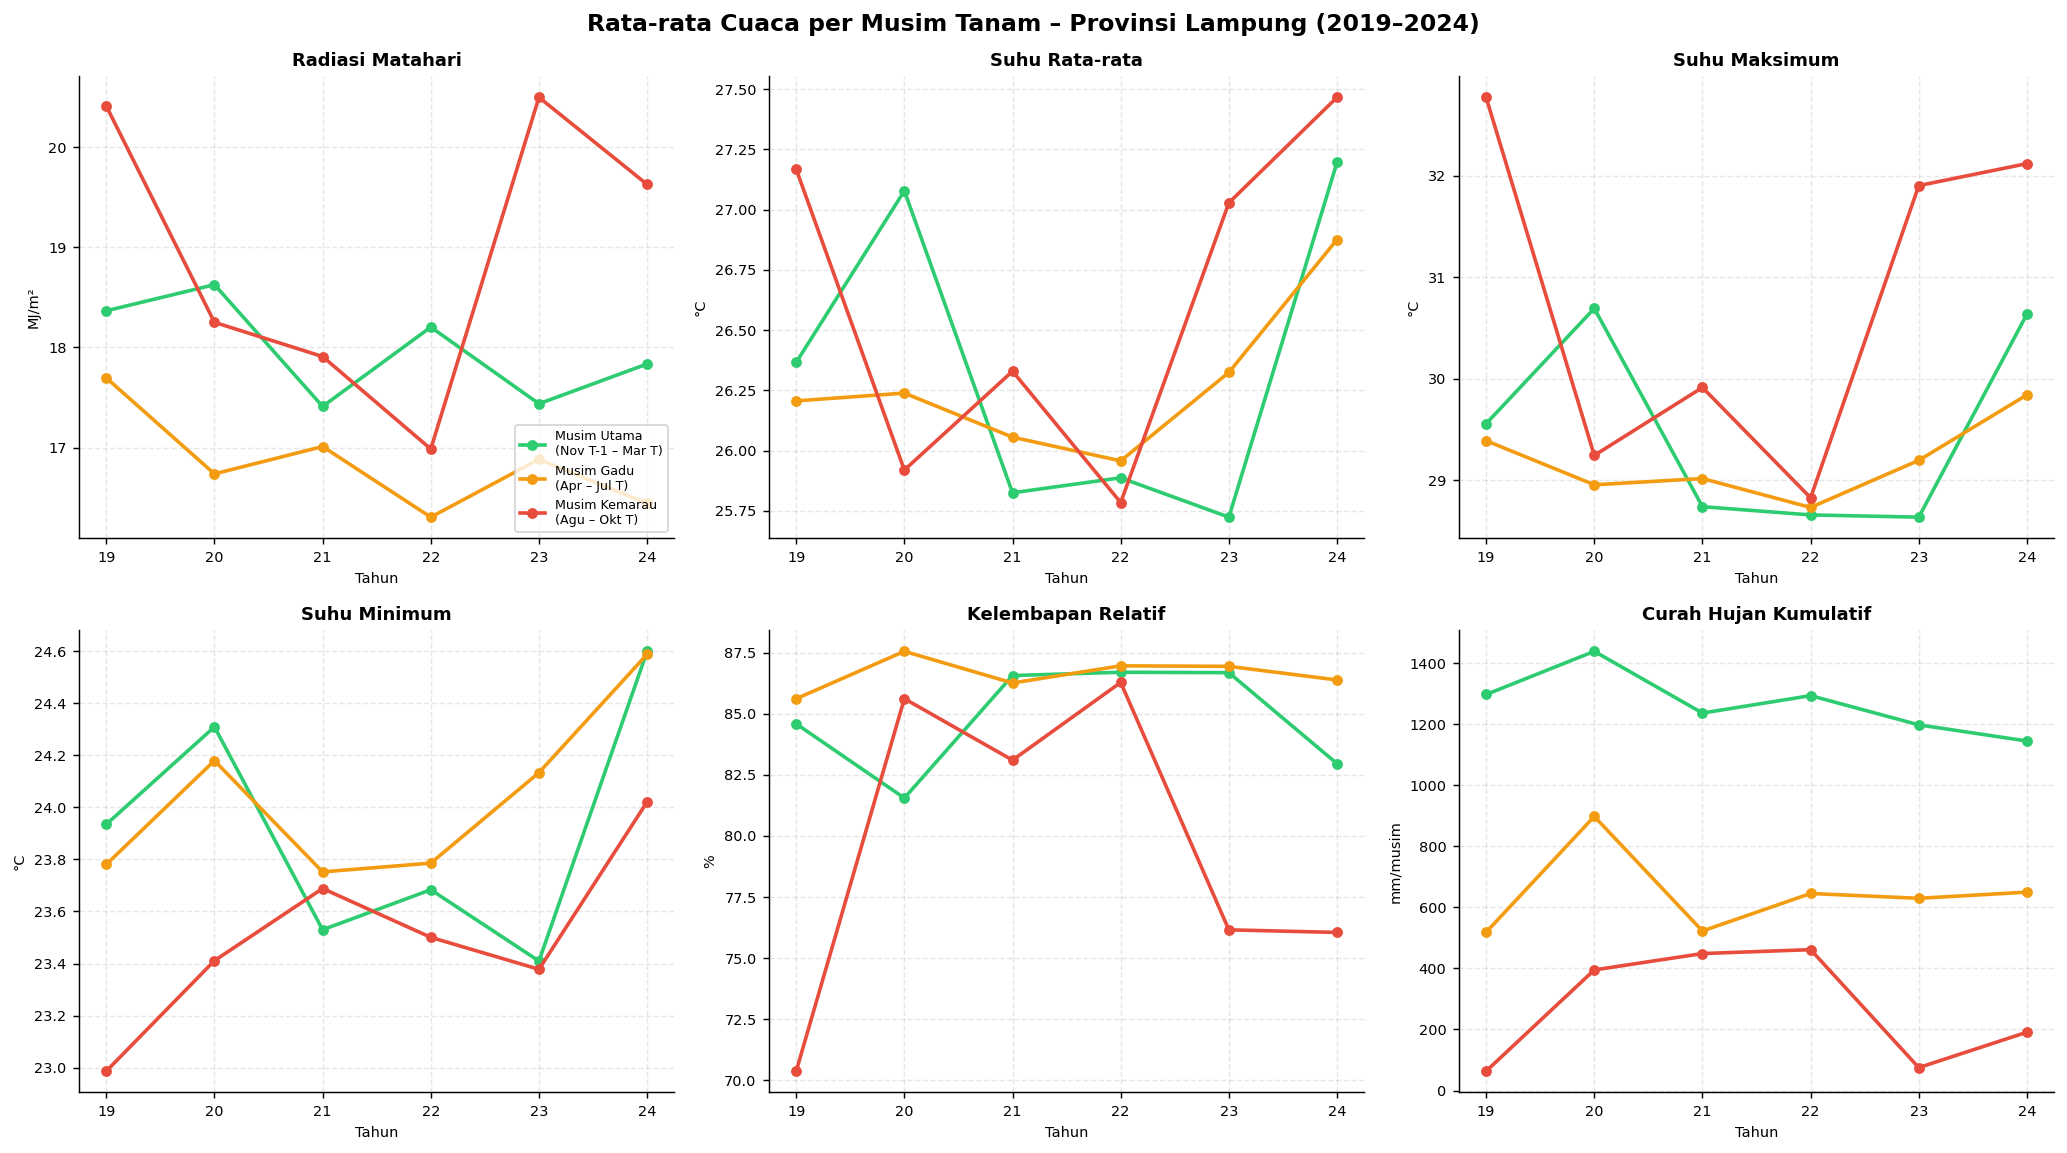

In [16]:
musim_label = {
    'utama'  : 'Musim Utama\n(Nov T-1 – Mar T)',
    'gadu'   : 'Musim Gadu\n(Apr – Jul T)',
    'kemarau': 'Musim Kemarau\n(Agu – Okt T)',
}
musim_warna = {'utama': '#2ecc71', 'gadu': '#f39c12', 'kemarau': '#e74c3c'}

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Rata-rata Cuaca per Musim Tanam – Provinsi Lampung (2019–2024)',
             fontsize=13, fontweight='bold')

param_plot = [
    ('ALLSKY_SFC_SW_DWN', 'Radiasi Matahari',      'MJ/m²'),
    ('T2M',               'Suhu Rata-rata',         '°C'),
    ('T2M_MAX',           'Suhu Maksimum',          '°C'),
    ('T2M_MIN',           'Suhu Minimum',           '°C'),
    ('RH2M',              'Kelembapan Relatif',     '%'),
    ('PRECTOTCORR',       'Curah Hujan Kumulatif',  'mm/musim'),
]

for idx, (param, label, unit) in enumerate(param_plot):
    ax = axes[idx // 3][idx % 3]
    for musim in ['utama', 'gadu', 'kemarau']:
        suffix = 'sum' if param == 'PRECTOTCORR' else 'mean'
        col = f'{param}_{musim}_{suffix}'
        if col not in df_fitur.columns:
            continue
        val = df_fitur.groupby('tahun')[col].mean()
        ax.plot(val.index, val.values, marker='o', linewidth=2,
                color=musim_warna[musim], label=musim_label[musim], markersize=5)
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.set_ylabel(unit, fontsize=8)
    ax.set_xlabel('Tahun', fontsize=8)
    ax.set_xticks(TAHUN_FITUR)
    ax.set_xticklabels([str(t)[2:] for t in TAHUN_FITUR], fontsize=8)
    ax.tick_params(axis='y', labelsize=8)
    if idx == 0:
        ax.legend(fontsize=7, loc='lower right')

plt.tight_layout()
plt.savefig('cuaca_musiman.png', bbox_inches='tight', dpi=130)
plt.show()

### 3.5 Korelasi Fitur Cuaca Musiman dengan Produktivitas

Korelasi Pearson antara fitur cuaca musiman dan target produktivitas (ton/ha).
Karena target sudah ternormalisasi per hektar, korelasi mencerminkan
hubungan agronomi yang lebih murni.

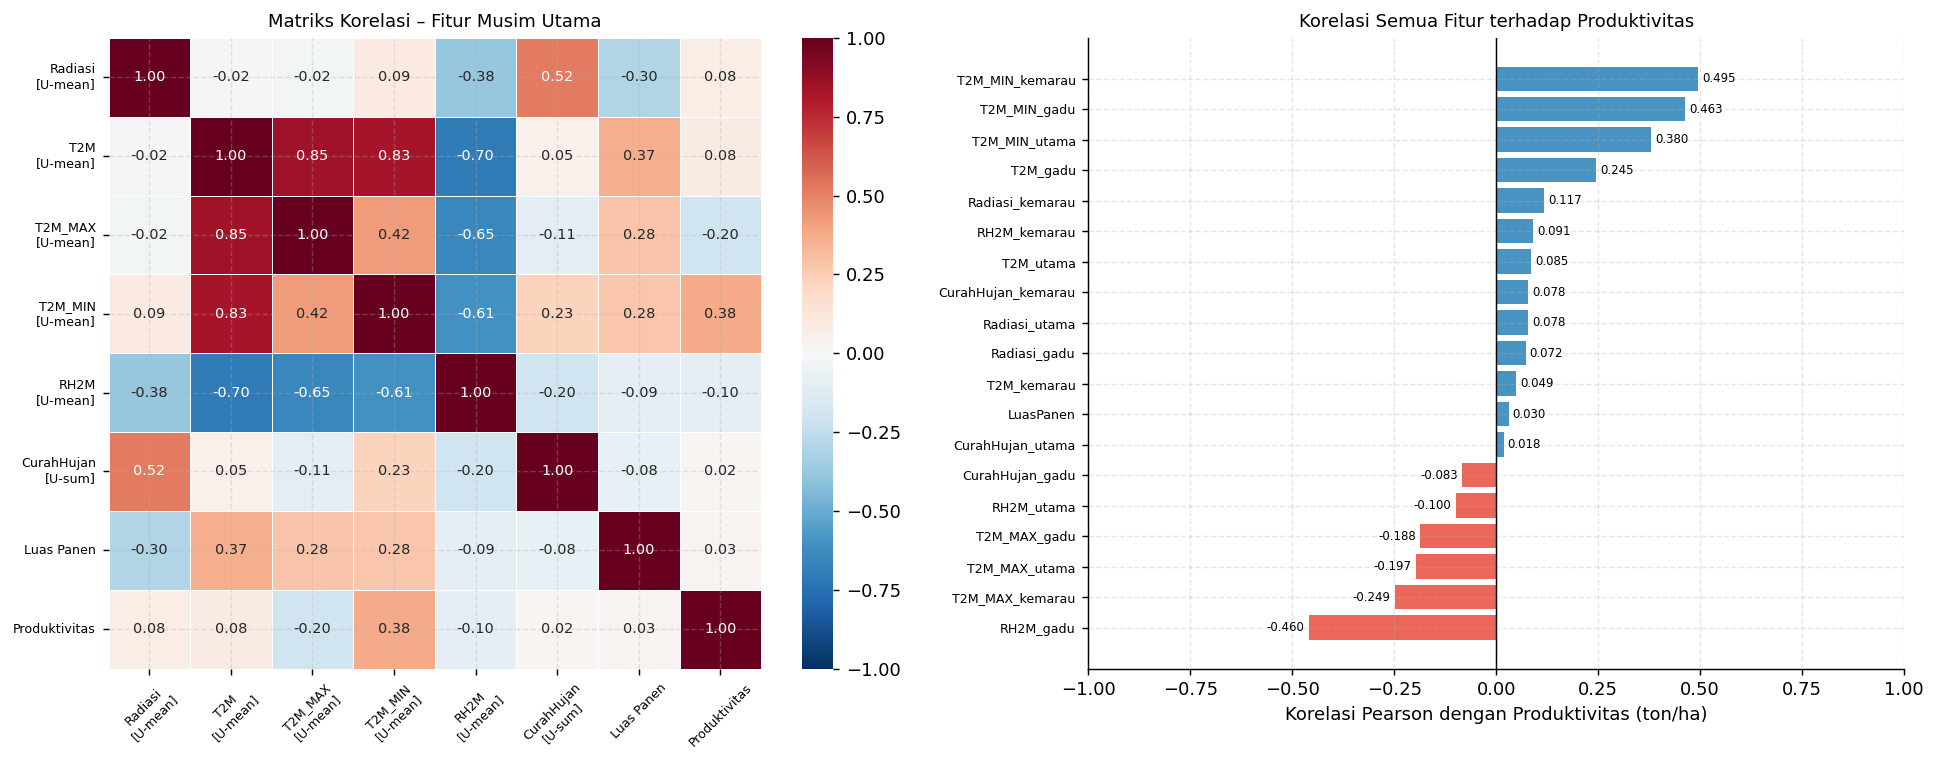

In [17]:
korel        = df_fitur[KOLOM_CUACA + ['luas_panen_ha', 'produktivitas_ton_per_ha']].corr()
korel_target = korel['produktivitas_ton_per_ha'].drop('produktivitas_ton_per_ha').sort_values()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Heatmap korelasi fitur Musim Utama
param_cols = [c for c in KOLOM_CUACA if 'utama' in c] + ['luas_panen_ha', 'produktivitas_ton_per_ha']
korel_sub  = df_fitur[param_cols].corr()
label_sub  = [c.replace('_utama_mean', '\n[U-mean]')
               .replace('_utama_sum',  '\n[U-sum]')
               .replace('ALLSKY_SFC_SW_DWN', 'Radiasi')
               .replace('PRECTOTCORR', 'CurahHujan')
               .replace('produktivitas_ton_per_ha', 'Produktivitas')
               .replace('luas_panen_ha', 'Luas Panen')
              for c in param_cols]
sns.heatmap(korel_sub, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            xticklabels=label_sub, yticklabels=label_sub, ax=axes[0],
            annot_kws={'size': 8}, vmin=-1, vmax=1, linewidths=0.3)
axes[0].set_title('Matriks Korelasi – Fitur Musim Utama', fontsize=10)
axes[0].tick_params(axis='x', labelsize=7, rotation=45)
axes[0].tick_params(axis='y', labelsize=7, rotation=0)

# Bar chart korelasi semua fitur
colors_bar = ['#e74c3c' if v < 0 else '#2980b9' for v in korel_target.values]
bars       = axes[1].barh(range(len(korel_target)), korel_target.values,
                          color=colors_bar, alpha=0.85)
axes[1].set_yticks(range(len(korel_target)))
axes[1].set_yticklabels(
    [c.replace('_mean', '').replace('_sum', '')
      .replace('ALLSKY_SFC_SW_DWN', 'Radiasi')
      .replace('PRECTOTCORR', 'CurahHujan')
      .replace('luas_panen_ha', 'LuasPanen')
     for c in korel_target.index],
    fontsize=7
)
for bar, val in zip(bars, korel_target.values):
    axes[1].text(val + (0.01 if val >= 0 else -0.01),
                 bar.get_y() + bar.get_height() / 2,
                 f'{val:.3f}', va='center',
                 ha='left' if val >= 0 else 'right', fontsize=6.5)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('Korelasi Pearson dengan Produktivitas (ton/ha)')
axes[1].set_title('Korelasi Semua Fitur terhadap Produktivitas', fontsize=10)
axes[1].set_xlim(-1, 1)

plt.tight_layout()
plt.savefig('korelasi_fitur.png', bbox_inches='tight', dpi=130)
plt.show()

---
## Section 4 – Pemodelan dan Evaluasi

### 4.1 Konfigurasi Model

#### Model ML

| Model | Alasan Pemilihan |
|---|---|
| **Ridge Regression** | Baseline linear; regularisasi L2 efektif pada rasio sampel/fitur rendah |
| **Random Forest** | Ensemble pohon; robust terhadap sampel kecil, menghasilkan feature importance |
| **Gradient Boosting** | Umumnya akurasi terbaik pada data tabular; diregularisasi `max_depth` & `subsample` |

#### Model Baseline (Acuan Minimum)

Setiap model ML *harus* melampaui baseline ini agar dianggap berguna:

| Baseline | Deskripsi |
|---|---|
| **Naive Mean** | Prediksi = rata-rata produktivitas seluruh data training |
| **Naive Kab Mean** | Prediksi = rata-rata historis produktivitas per kabupaten |

> **Mengapa baseline penting?** Target produktivitas memiliki koefisien variasi
> hanya ~9%. Artinya prediksi naif "selalu rata-rata" sudah menghasilkan MAPE ≈ 9%
> tanpa belajar apapun. Model ML baru bermakna jika MAPE-nya jauh lebih kecil dari ini.

In [18]:
# ── Model ML ─────────────────────────────────────────────────────────────────
MODELDEFS = {
    'Ridge Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model',  Ridge(alpha=10.0)),
    ]),
    'Random Forest': RandomForestRegressor(
        n_estimators     = 300,
        max_depth        = 5,
        min_samples_leaf = 3,
        max_features     = 'sqrt',
        random_state     = 42,
        n_jobs           = -1,
    ),
    'Gradient Boosting': GradientBoostingRegressor(
        n_estimators     = 150,
        max_depth        = 3,
        learning_rate    = 0.08,
        subsample        = 0.8,
        min_samples_leaf = 3,
        random_state     = 42,
    ),
}

# ── Model Baseline ────────────────────────────────────────────────────────────
class NaiveMeanRegressor:
    """Prediksi selalu rata-rata target dari data training."""
    def fit(self, X, y, **kw):
        self.mean_ = float(np.mean(y))
        return self
    def predict(self, X):
        return np.full(len(X), self.mean_)

class NaiveKabMeanRegressor:
    """Prediksi rata-rata historis per kabupaten dari data training."""
    def fit(self, X_meta, y, **kw):
        # X_meta: DataFrame dengan kolom 'kabupaten' dan 'produktivitas_ton_per_ha'
        self.kab_mean_  = X_meta.groupby('kabupaten')['produktivitas_ton_per_ha'].mean()
        self.global_mean_ = float(np.mean(y))
        return self
    def predict(self, X_meta):
        return (X_meta['kabupaten']
                .map(self.kab_mean_)
                .fillna(self.global_mean_)
                .values)

SEMUA_MODEL = list(MODELDEFS.keys()) + ['Naive Mean', 'Naive Kab Mean']

print("Konfigurasi model ML:")
for name, mdl in MODELDEFS.items():
    if hasattr(mdl, 'steps'):
        params = mdl.named_steps['model'].get_params()
    else:
        params = {k: v for k, v in mdl.get_params().items()
                  if k in ('n_estimators', 'max_depth', 'learning_rate',
                            'subsample', 'alpha', 'min_samples_leaf')}
    print(f"  {name}: {params}")
print()
print("Baseline model: Naive Mean, Naive Kab Mean")

Konfigurasi model ML:
  Ridge Regression: {'alpha': 10.0, 'copy_X': True, 'fit_intercept': True, 'max_iter': None, 'positive': False, 'random_state': None, 'solver': 'auto', 'tol': 0.0001}
  Random Forest: {'max_depth': 5, 'min_samples_leaf': 3, 'n_estimators': 300}
  Gradient Boosting: {'alpha': 0.9, 'learning_rate': 0.08, 'max_depth': 3, 'min_samples_leaf': 3, 'n_estimators': 150, 'subsample': 0.8}

Baseline model: Naive Mean, Naive Kab Mean


### 4.2 Walk-Forward Validation

**[FIX v3] Penggantian LOYOCV → Walk-Forward Validation**

Masalah pada LOYOCV versi sebelumnya: fold pertama menguji tahun 2019 tetapi
dilatih menggunakan tahun 2020–2024 (data *masa depan*) — ini adalah **temporal leakage**.

Walk-Forward Validation menjamin data training selalu berasal dari tahun *sebelum*
tahun test:

```
Fold 1: Train [2019]           → Test 2020  (15 train, 15 test)
Fold 2: Train [2019–2020]      → Test 2021  (30 train, 15 test)
Fold 3: Train [2019–2021]      → Test 2022  (45 train, 15 test)
Fold 4: Train [2019–2022]      → Test 2023  (60 train, 15 test)
Fold 5: Train [2019–2023]      → Test 2024  (75 train, 15 test)
```

> **Catatan fold awal:** Fold 1 hanya memiliki 15 sampel training untuk
> ~33 fitur — rasio sangat rendah. Ridge (regularisasi kuat) lebih stabil
> di kondisi ini; RF dan GB di fold awal perlu diinterpretasikan dengan hati-hati.

In [19]:
def hitung_mape(y_true, y_pred, eps=1e-8):
    return np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + eps))) * 100

# Struktur penyimpanan hasil
WFV_HASIL = {
    nm: {'rmse': [], 'mae': [], 'r2': [], 'mape': [],
         'tahun': [], 'y_true': [], 'y_pred': []}
    for nm in SEMUA_MODEL
}

TAHUN_TEST_WFV = TAHUN_FITUR[1:]   # test mulai 2020 (butuh ≥1 tahun training)

print("Walk-Forward Validation")
print("=" * 65)

for tahun_test in TAHUN_TEST_WFV:
    train_mask = df_fitur['tahun'] < tahun_test
    test_mask  = df_fitur['tahun'] == tahun_test

    X_tr = df_model[train_mask][FITUR_MODEL].values.astype(float)
    y_tr = df_model[train_mask]['produktivitas_ton_per_ha'].values
    X_te = df_model[test_mask][FITUR_MODEL].values.astype(float)
    y_te = df_model[test_mask]['produktivitas_ton_per_ha'].values

    meta_tr = df_fitur[train_mask]
    meta_te = df_fitur[test_mask]

    tahun_train_str = (f"{TAHUN_FITUR[0]}–{tahun_test-1}"
                       if tahun_test - 1 > TAHUN_FITUR[0]
                       else str(TAHUN_FITUR[0]))
    print(f"  Fold {tahun_test} | Train: {tahun_train_str} "
          f"({len(y_tr):>2} sampel) | Test: {tahun_test} (15 sampel)")

    # ── Model ML ──────────────────────────────────────────────────────────────
    for name, mdl_def in MODELDEFS.items():
        m    = copy.deepcopy(mdl_def)
        m.fit(X_tr, y_tr)
        y_pr = np.clip(m.predict(X_te), 0, None)

        WFV_HASIL[name]['rmse'].append(np.sqrt(mean_squared_error(y_te, y_pr)))
        WFV_HASIL[name]['mae'].append(mean_absolute_error(y_te, y_pr))
        WFV_HASIL[name]['r2'].append(r2_score(y_te, y_pr))
        WFV_HASIL[name]['mape'].append(hitung_mape(y_te, y_pr))
        WFV_HASIL[name]['tahun'].append(tahun_test)
        WFV_HASIL[name]['y_true'].extend(y_te.tolist())
        WFV_HASIL[name]['y_pred'].extend(y_pr.tolist())

    # ── Naive Mean ────────────────────────────────────────────────────────────
    nm_model = NaiveMeanRegressor().fit(X_tr, y_tr)
    y_pr_nm  = nm_model.predict(X_te)
    WFV_HASIL['Naive Mean']['rmse'].append(np.sqrt(mean_squared_error(y_te, y_pr_nm)))
    WFV_HASIL['Naive Mean']['mae'].append(mean_absolute_error(y_te, y_pr_nm))
    WFV_HASIL['Naive Mean']['r2'].append(r2_score(y_te, y_pr_nm))
    WFV_HASIL['Naive Mean']['mape'].append(hitung_mape(y_te, y_pr_nm))
    WFV_HASIL['Naive Mean']['tahun'].append(tahun_test)
    WFV_HASIL['Naive Mean']['y_true'].extend(y_te.tolist())
    WFV_HASIL['Naive Mean']['y_pred'].extend(y_pr_nm.tolist())

    # ── Naive Kab Mean ────────────────────────────────────────────────────────
    nk_model = NaiveKabMeanRegressor().fit(meta_tr, y_tr)
    y_pr_nk  = nk_model.predict(meta_te)
    WFV_HASIL['Naive Kab Mean']['rmse'].append(np.sqrt(mean_squared_error(y_te, y_pr_nk)))
    WFV_HASIL['Naive Kab Mean']['mae'].append(mean_absolute_error(y_te, y_pr_nk))
    WFV_HASIL['Naive Kab Mean']['r2'].append(r2_score(y_te, y_pr_nk))
    WFV_HASIL['Naive Kab Mean']['mape'].append(hitung_mape(y_te, y_pr_nk))
    WFV_HASIL['Naive Kab Mean']['tahun'].append(tahun_test)
    WFV_HASIL['Naive Kab Mean']['y_true'].extend(y_te.tolist())
    WFV_HASIL['Naive Kab Mean']['y_pred'].extend(y_pr_nk.tolist())

print()
print("Selesai.")

Walk-Forward Validation
  Fold 2020 | Train: 2019 (15 sampel) | Test: 2020 (15 sampel)
  Fold 2021 | Train: 2019–2020 (30 sampel) | Test: 2021 (15 sampel)
  Fold 2022 | Train: 2019–2021 (45 sampel) | Test: 2022 (15 sampel)
  Fold 2023 | Train: 2019–2022 (60 sampel) | Test: 2023 (15 sampel)
  Fold 2024 | Train: 2019–2023 (75 sampel) | Test: 2024 (15 sampel)

Selesai.


### 4.3 Perbandingan Performa Model (Walk-Forward CV)

In [20]:
# Tabel ringkasan
rows_cv = []
for name in SEMUA_MODEL:
    h = WFV_HASIL[name]
    rows_cv.append({
        'Model'         : name,
        'RMSE mean'     : np.mean(h['rmse']),
        'RMSE std'      : np.std(h['rmse']),
        'MAE mean'      : np.mean(h['mae']),
        'R2 mean'       : np.mean(h['r2']),
        'MAPE mean (%)'  : np.mean(h['mape']),
        'MAPE std (%)'   : np.std(h['mape']),
    })

df_cv_summary = (pd.DataFrame(rows_cv)
                 .set_index('Model')
                 .sort_values('MAPE mean (%)'))

print("Hasil Walk-Forward Validation (Produktivitas ton/ha)  –  5 fold (2020–2024)")
print("=" * 72)
print(df_cv_summary.round(4).to_string())
print()

# Baseline MAPE sebagai referensi
mape_naive_mean = df_cv_summary.loc['Naive Mean', 'MAPE mean (%)']
mape_naive_kab  = df_cv_summary.loc['Naive Kab Mean', 'MAPE mean (%)']
print(f"Referensi Baseline:")
print(f"  Naive Mean     : MAPE = {mape_naive_mean:.2f}%  ← batas bawah 'tidak ada informasi'")
print(f"  Naive Kab Mean : MAPE = {mape_naive_kab:.2f}%  ← baseline dengan info lokasi")
print()

# Model terbaik dari ML (bukan baseline)
ml_models_only = df_cv_summary.loc[list(MODELDEFS.keys())]
MODEL_TERBAIK  = ml_models_only['MAPE mean (%)'].idxmin()
mape_terbaik   = ml_models_only.loc[MODEL_TERBAIK, 'MAPE mean (%)']

print(f"Model ML Terbaik  : {MODEL_TERBAIK}  (MAPE = {mape_terbaik:.2f}%)")

# Cek apakah model terbaik melampaui baseline
if mape_terbaik < mape_naive_kab:
    selisih = mape_naive_kab - mape_terbaik
    print(f"  → Unggul {selisih:.2f}% poin di atas Naive Kab Mean  ✓")
else:
    print(f"  [PERINGATAN] Model terbaik tidak melampaui Naive Kab Mean — "
          f"model tidak memberikan nilai tambah.")

Hasil Walk-Forward Validation (Produktivitas ton/ha)  –  5 fold (2020–2024)
                   RMSE mean  RMSE std  MAE mean  R2 mean  MAPE mean (%)  MAPE std (%)
Model                                                                                 
Naive Kab Mean        0.4545    0.0670    0.3817   0.3019         7.4786        1.0862
Ridge Regression      0.4904    0.1361    0.4178   0.1181         8.1410        2.5858
Random Forest         0.5386    0.0268    0.4263   0.0193         8.1672        0.4267
Gradient Boosting     0.5241    0.1082    0.4399   0.0193         8.5433        1.9854
Naive Mean            0.5943    0.0106    0.4807  -0.1943         9.2591        0.8014

Referensi Baseline:
  Naive Mean     : MAPE = 9.26%  ← batas bawah 'tidak ada informasi'
  Naive Kab Mean : MAPE = 7.48%  ← baseline dengan info lokasi

Model ML Terbaik  : Ridge Regression  (MAPE = 8.14%)
  [PERINGATAN] Model terbaik tidak melampaui Naive Kab Mean — model tidak memberikan nilai tambah.


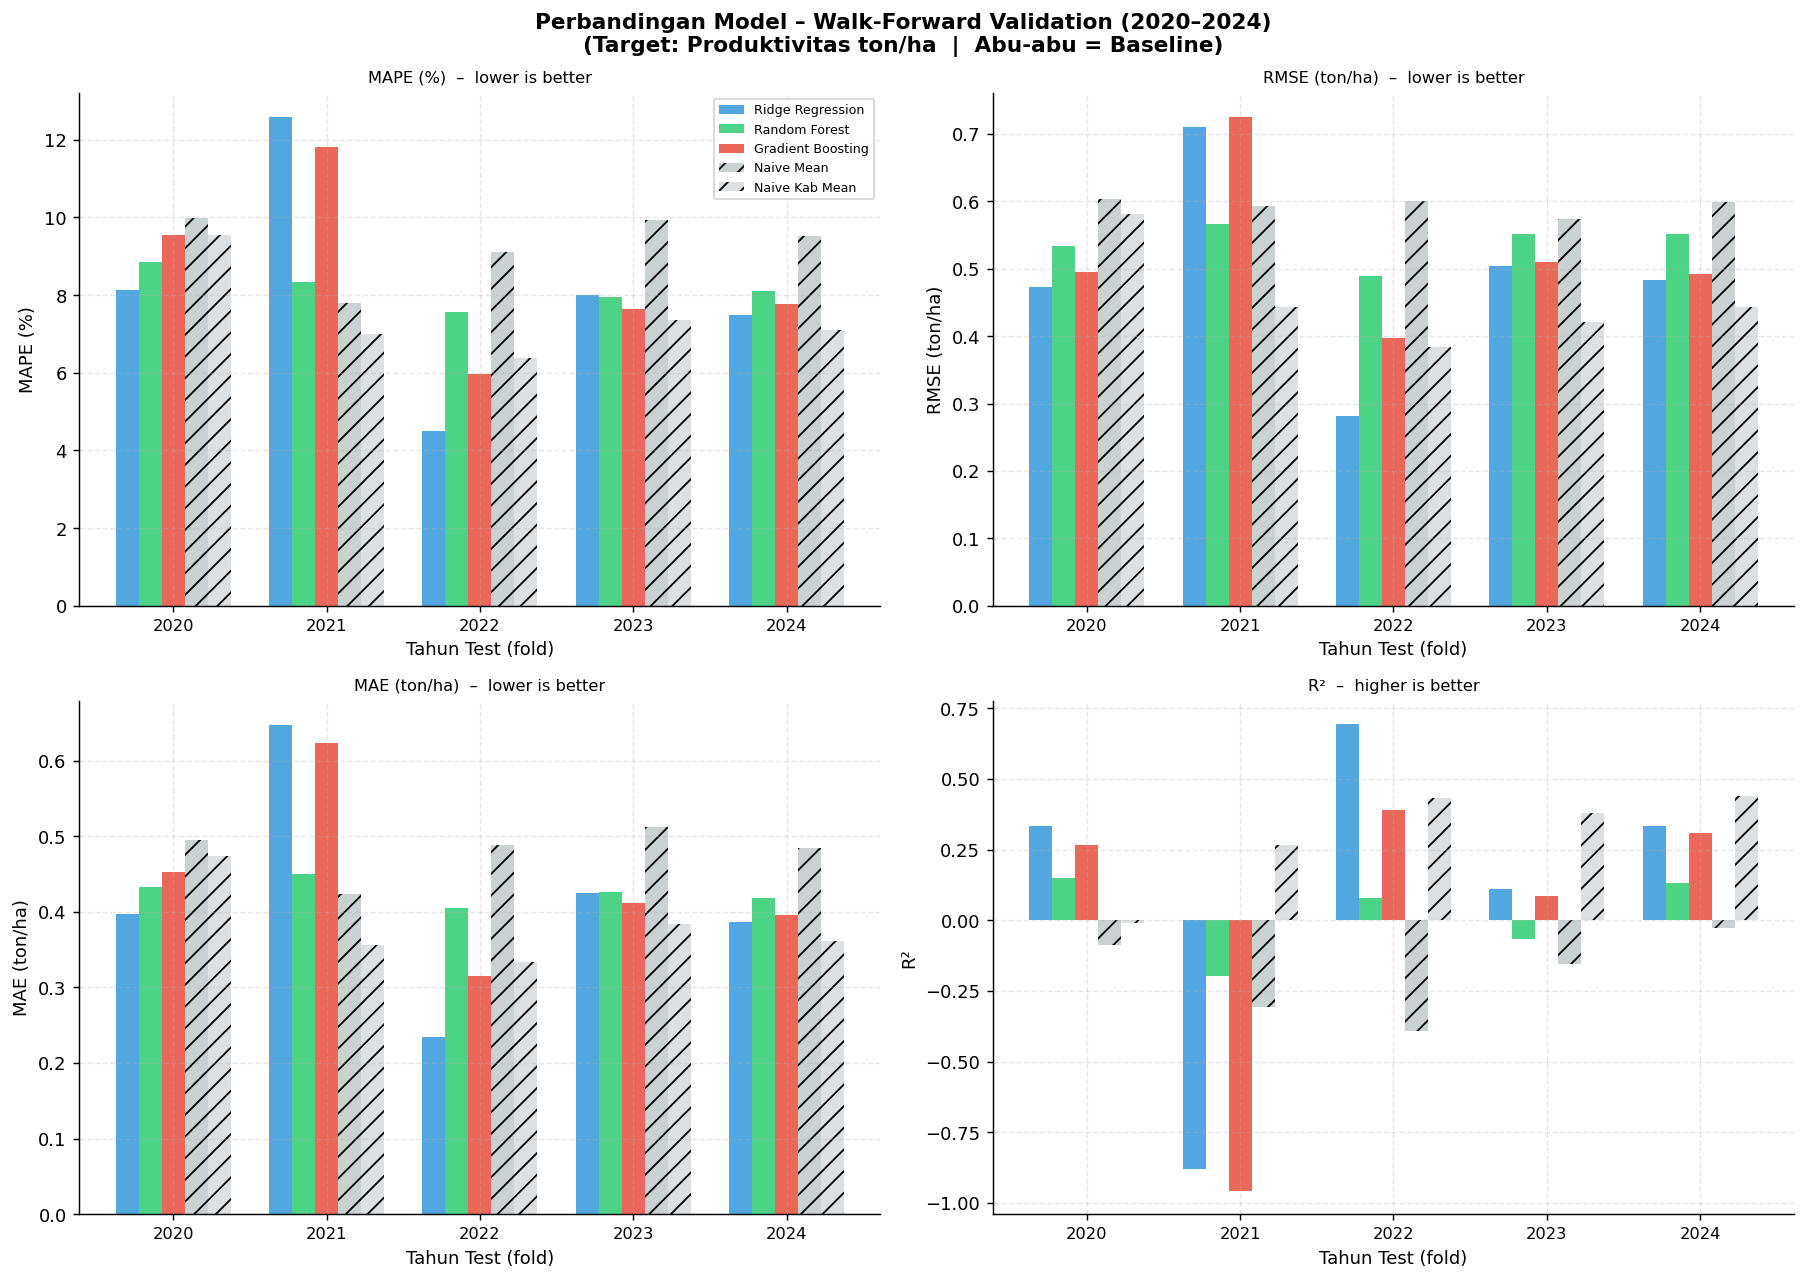

In [21]:
# Visualisasi perbandingan per fold
model_colors = {
    'Ridge Regression'  : '#3498db',
    'Random Forest'     : '#2ecc71',
    'Gradient Boosting' : '#e74c3c',
    'Naive Mean'        : '#95a5a6',
    'Naive Kab Mean'    : '#bdc3c7',
}
metrik_plot = [
    ('mape', 'MAPE (%)',      'lower is better'),
    ('rmse', 'RMSE (ton/ha)', 'lower is better'),
    ('mae',  'MAE (ton/ha)',  'lower is better'),
    ('r2',   'R²',            'higher is better'),
]

n_fold = len(TAHUN_TEST_WFV)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Perbandingan Model – Walk-Forward Validation (2020–2024)\n'
             '(Target: Produktivitas ton/ha  |  Abu-abu = Baseline)',
             fontsize=12, fontweight='bold')

for ax, (metrik, ylabel, note) in zip(axes.flat, metrik_plot):
    x_pos = np.arange(n_fold)
    n_mdl = len(SEMUA_MODEL)
    width = 0.75 / n_mdl

    for i, name in enumerate(SEMUA_MODEL):
        vals    = WFV_HASIL[name][metrik]
        is_base = name.startswith('Naive')
        alpha   = 0.5 if is_base else 0.85
        hatch   = '//' if is_base else ''
        ax.bar(x_pos + i * width, vals, width=width,
               color=model_colors[name], alpha=alpha,
               label=name, hatch=hatch)

    ax.set_xticks(x_pos + width * (n_mdl - 1) / 2)
    ax.set_xticklabels([str(t) for t in TAHUN_TEST_WFV], fontsize=9)
    ax.set_xlabel('Tahun Test (fold)')
    ax.set_ylabel(ylabel)
    ax.set_title(f'{ylabel}  –  {note}', fontsize=9)

axes.flat[0].legend(fontsize=7, loc='upper right')
plt.tight_layout()
plt.savefig('perbandingan_model_wfv.png', bbox_inches='tight', dpi=130)
plt.show()

### 4.4 Evaluasi Final – Model Terbaik (Train 2019–2023 / Test 2024)

Evaluasi akhir menggunakan split kronologis paling realistis:  
melatih pada seluruh data historis (2019–2023) dan menguji pada tahun terbaru (2024).

> **Catatan interpretasi R²:**  
> Dua metrik R² yang dilaporkan di bawah ini terlihat kontradiktif — R²
> *produktivitas* bisa negatif sementara R² *produksi* bisa sangat tinggi.
> Ini **bukan** inkonsistensi; ini artefak matematis:  
> Produksi = Produktivitas × Luas_Panen. Variansi luas panen antar kabupaten
> jauh lebih besar daripada variansi produktivitas, sehingga R² produksi
> didominasi oleh variansi luas — bukan kemampuan prediksi model.  
> **Gunakan R² produktivitas sebagai ukuran kemampuan model yang sesungguhnya.**

In [22]:
mask_train = df_fitur['tahun'] <= 2023
mask_test  = df_fitur['tahun'] == 2024

X_train  = df_model[mask_train][FITUR_MODEL].values.astype(float)
y_train  = df_model[mask_train]['produktivitas_ton_per_ha'].values
X_test   = df_model[mask_test][FITUR_MODEL].values.astype(float)
y_test   = df_model[mask_test]['produktivitas_ton_per_ha'].values
meta_test = df_fitur[mask_test].copy().reset_index(drop=True)

# Train model ML terbaik
model_final = copy.deepcopy(MODELDEFS[MODEL_TERBAIK])
model_final.fit(X_train, y_train)
y_pred_prodvt = np.clip(model_final.predict(X_test), 0, None)

# Train baseline terbaik
meta_train = df_fitur[mask_train]
nk_final   = NaiveKabMeanRegressor().fit(meta_train, y_train)
y_pred_nk  = nk_final.predict(meta_test)

# Prediksi produksi (turunan)
meta_test['prodvt_aktual']         = y_test
meta_test['prodvt_prediksi']       = y_pred_prodvt
meta_test['produksi_prediksi_ton'] = y_pred_prodvt * meta_test['luas_panen_ha']

def metrik_set(y_true, y_pred, label):
    return {
        'label': label,
        'RMSE' : np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAE'  : mean_absolute_error(y_true, y_pred),
        'R2'   : r2_score(y_true, y_pred),
        'MAPE' : hitung_mape(y_true, y_pred),
    }

# Metrik produktivitas
m_prodvt_ml = metrik_set(y_test, y_pred_prodvt, MODEL_TERBAIK)
m_prodvt_nk = metrik_set(y_test, y_pred_nk,     'Naive Kab Mean')

# Metrik produksi (turunan)
y_prod_akt  = meta_test['produksi_ton'].values
y_prod_pred = meta_test['produksi_prediksi_ton'].values
rmse_prod = np.sqrt(mean_squared_error(y_prod_akt, y_prod_pred))
r2_prod   = r2_score(y_prod_akt, y_prod_pred)
mape_prod = hitung_mape(y_prod_akt, y_prod_pred)

sep = '=' * 65
print(sep)
print(f"EVALUASI FINAL – {MODEL_TERBAIK}")
print(f"Training: 2019–2023 ({X_train.shape[0]} sampel)  |  Test: 2024 (15 sampel)")
print(sep)
print()
print("Metrik Produktivitas (ton/ha)  ← ukuran kemampuan model sesungguhnya:")
print(f"  {'Model':<22} {'RMSE':>8} {'MAE':>8} {'R²':>8} {'MAPE':>8}")
print(f"  {'-'*56}")
for m in [m_prodvt_ml, m_prodvt_nk]:
    print(f"  {m['label']:<22} {m['RMSE']:>8.4f} {m['MAE']:>8.4f} "
          f"{m['R2']:>8.4f} {m['MAPE']:>7.2f}%")
print()
print("Metrik Produksi Turunan (ton)  ← HATI-HATI: R² dipengaruhi variansi luas panen:")
print(f"  RMSE  : {rmse_prod:,.0f} ton")
print(f"  R²    : {r2_prod:.4f}  ← tinggi karena dominasi variansi luas, BUKAN bukti model bagus")
print(f"  MAPE  : {mape_prod:.2f}%")

EVALUASI FINAL – Ridge Regression
Training: 2019–2023 (75 sampel)  |  Test: 2024 (15 sampel)

Metrik Produktivitas (ton/ha)  ← ukuran kemampuan model sesungguhnya:
  Model                      RMSE      MAE       R²     MAPE
  --------------------------------------------------------
  Ridge Regression         0.4829   0.3866   0.3343    7.48%
  Naive Kab Mean           0.4437   0.3613   0.4379    7.10%

Metrik Produksi Turunan (ton)  ← HATI-HATI: R² dipengaruhi variansi luas panen:
  RMSE  : 29,104 ton
  R²    : 0.9735  ← tinggi karena dominasi variansi luas, BUKAN bukti model bagus
  MAPE  : 7.48%


---
## Section 5 – Visualisasi Final

### 5.1 Scatter Plot Prediksi vs Aktual (Test 2024)

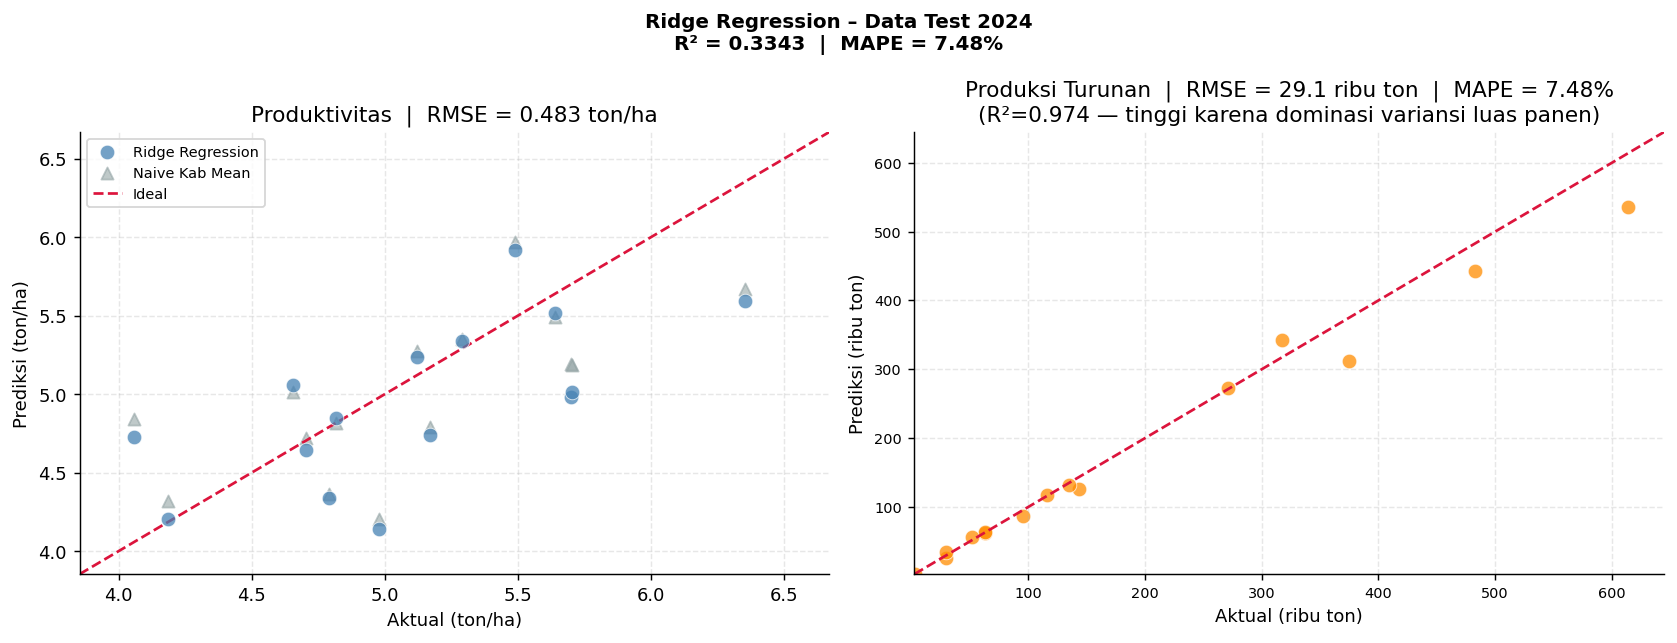

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f'{MODEL_TERBAIK} – Data Test 2024\n'
             f'R² = {m_prodvt_ml["R2"]:.4f}  |  MAPE = {m_prodvt_ml["MAPE"]:.2f}%',
             fontsize=11, fontweight='bold')

# Scatter produktivitas
ax = axes[0]
ax.scatter(y_test, y_pred_prodvt, color='steelblue', alpha=0.75,
           s=65, edgecolors='white', linewidth=0.5, zorder=3, label=MODEL_TERBAIK)
ax.scatter(y_test, y_pred_nk, color='#95a5a6', alpha=0.6,
           s=45, marker='^', zorder=2, label='Naive Kab Mean')
lim = [min(y_test.min(), y_pred_prodvt.min()) * 0.95,
       max(y_test.max(), y_pred_prodvt.max()) * 1.05]
ax.plot(lim, lim, '--', color='crimson', linewidth=1.5, label='Ideal')
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel('Aktual (ton/ha)')
ax.set_ylabel('Prediksi (ton/ha)')
ax.set_title(f'Produktivitas  |  RMSE = {m_prodvt_ml["RMSE"]:.3f} ton/ha')
ax.legend(fontsize=8)

# Scatter produksi turunan
ax = axes[1]
ax.scatter(y_prod_akt / 1e3, y_prod_pred / 1e3,
           color='darkorange', alpha=0.75, s=65, edgecolors='white', linewidth=0.5)
lim2 = [min(y_prod_akt.min(), y_prod_pred.min()) / 1e3 * 0.9,
        max(y_prod_akt.max(), y_prod_pred.max()) / 1e3 * 1.05]
ax.plot(lim2, lim2, '--', color='crimson', linewidth=1.5)
ax.set_xlim(lim2); ax.set_ylim(lim2)
ax.set_xlabel('Aktual (ribu ton)')
ax.set_ylabel('Prediksi (ribu ton)')
ax.set_title(f'Produksi Turunan  |  RMSE = {rmse_prod/1e3:.1f} ribu ton  |  MAPE = {mape_prod:.2f}%\n'
             f'(R²={r2_prod:.3f} — tinggi karena dominasi variansi luas panen)')
ax.tick_params(labelsize=8)

plt.tight_layout()
plt.savefig('scatter_prediksi_aktual.png', bbox_inches='tight', dpi=130)
plt.show()

### 5.2 Perbandingan Produksi Aktual vs Prediksi per Kabupaten (2024)

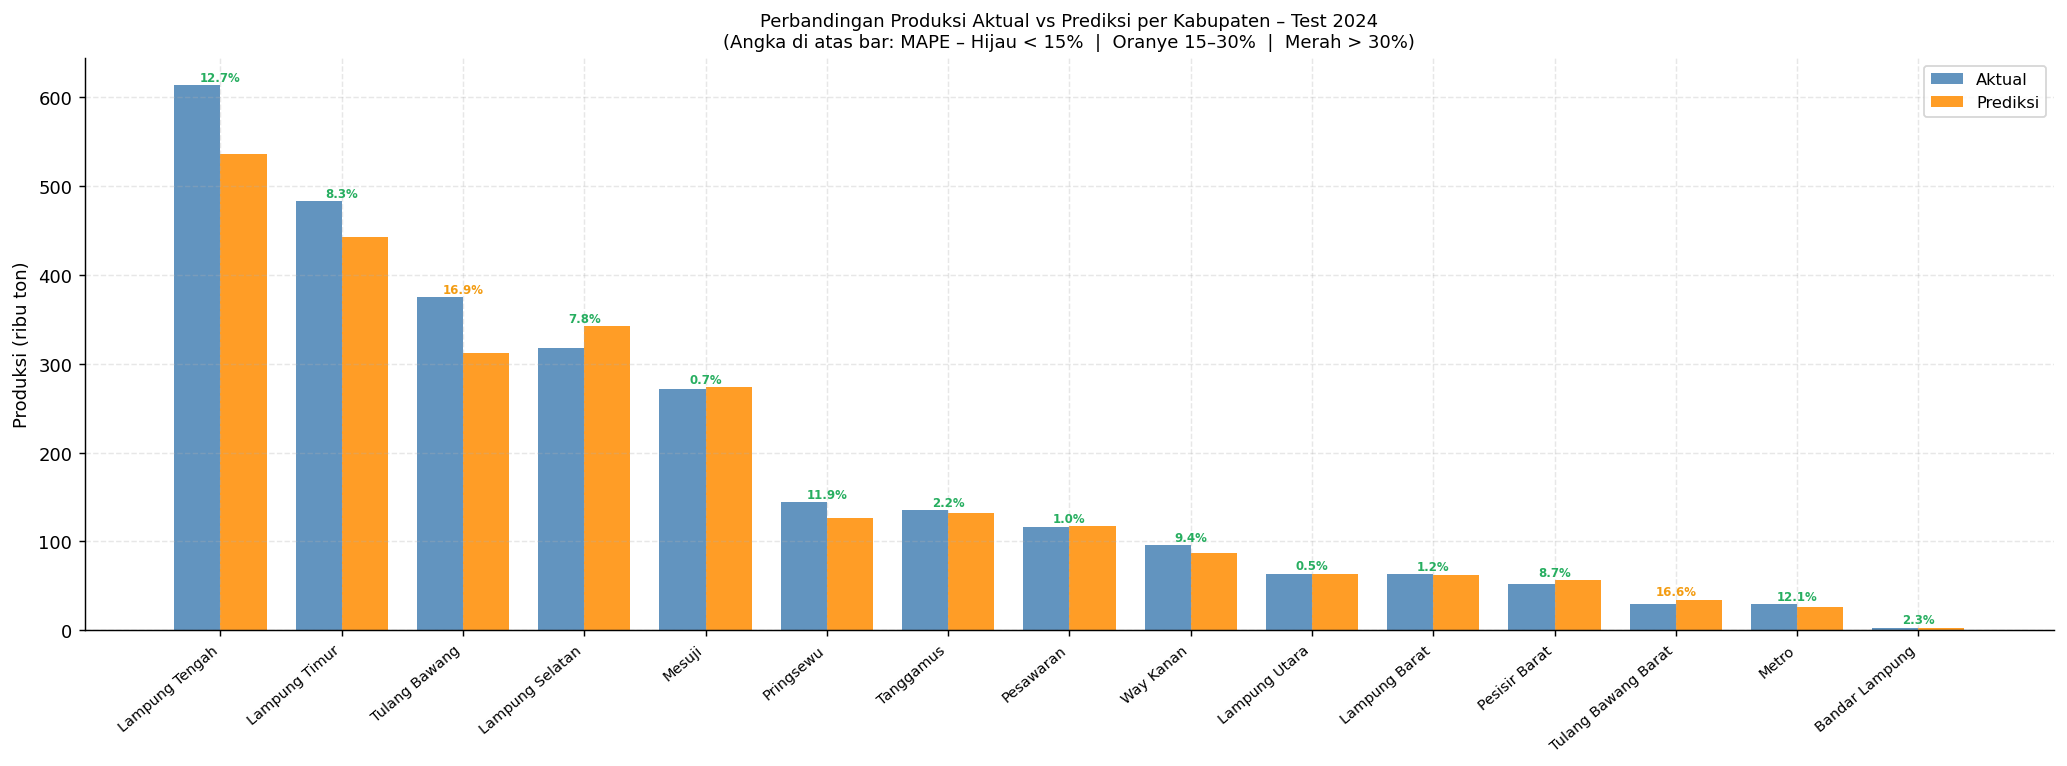

In [24]:
kab_sorted = meta_test.sort_values('produksi_ton', ascending=False)['kabupaten'].values
x_pos      = np.arange(len(kab_sorted))
width      = 0.38

akt_vals  = [meta_test[meta_test['kabupaten'] == k]['produksi_ton'].values[0] / 1e3
             for k in kab_sorted]
pred_vals = [meta_test[meta_test['kabupaten'] == k]['produksi_prediksi_ton'].values[0] / 1e3
             for k in kab_sorted]
mape_vals = [abs(a - p) / max(a, 1e-8) * 100 for a, p in zip(akt_vals, pred_vals)]

fig, ax = plt.subplots(figsize=(16, 6))
ax.bar(x_pos - width / 2, akt_vals,  width=width, color='steelblue',
       alpha=0.85, label='Aktual')
ax.bar(x_pos + width / 2, pred_vals, width=width, color='darkorange',
       alpha=0.85, label='Prediksi')

for i, (a, p, mp) in enumerate(zip(akt_vals, pred_vals, mape_vals)):
    clr = '#27ae60' if mp < 15 else ('#f39c12' if mp < 30 else '#e74c3c')
    ax.text(x_pos[i], max(a, p) + 1.5, f'{mp:.1f}%',
            ha='center', va='bottom', fontsize=6.5, color=clr, fontweight='bold')

ax.set_xticks(x_pos)
ax.set_xticklabels(kab_sorted, rotation=40, ha='right', fontsize=8)
ax.set_ylabel('Produksi (ribu ton)')
ax.set_title(f'Perbandingan Produksi Aktual vs Prediksi per Kabupaten – Test 2024\n'
             f'(Angka di atas bar: MAPE – Hijau < 15%  |  Oranye 15–30%  |  Merah > 30%)',
             fontsize=10)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('bar_per_kabupaten_2024.png', bbox_inches='tight', dpi=130)
plt.show()

### 5.3 Feature Importance

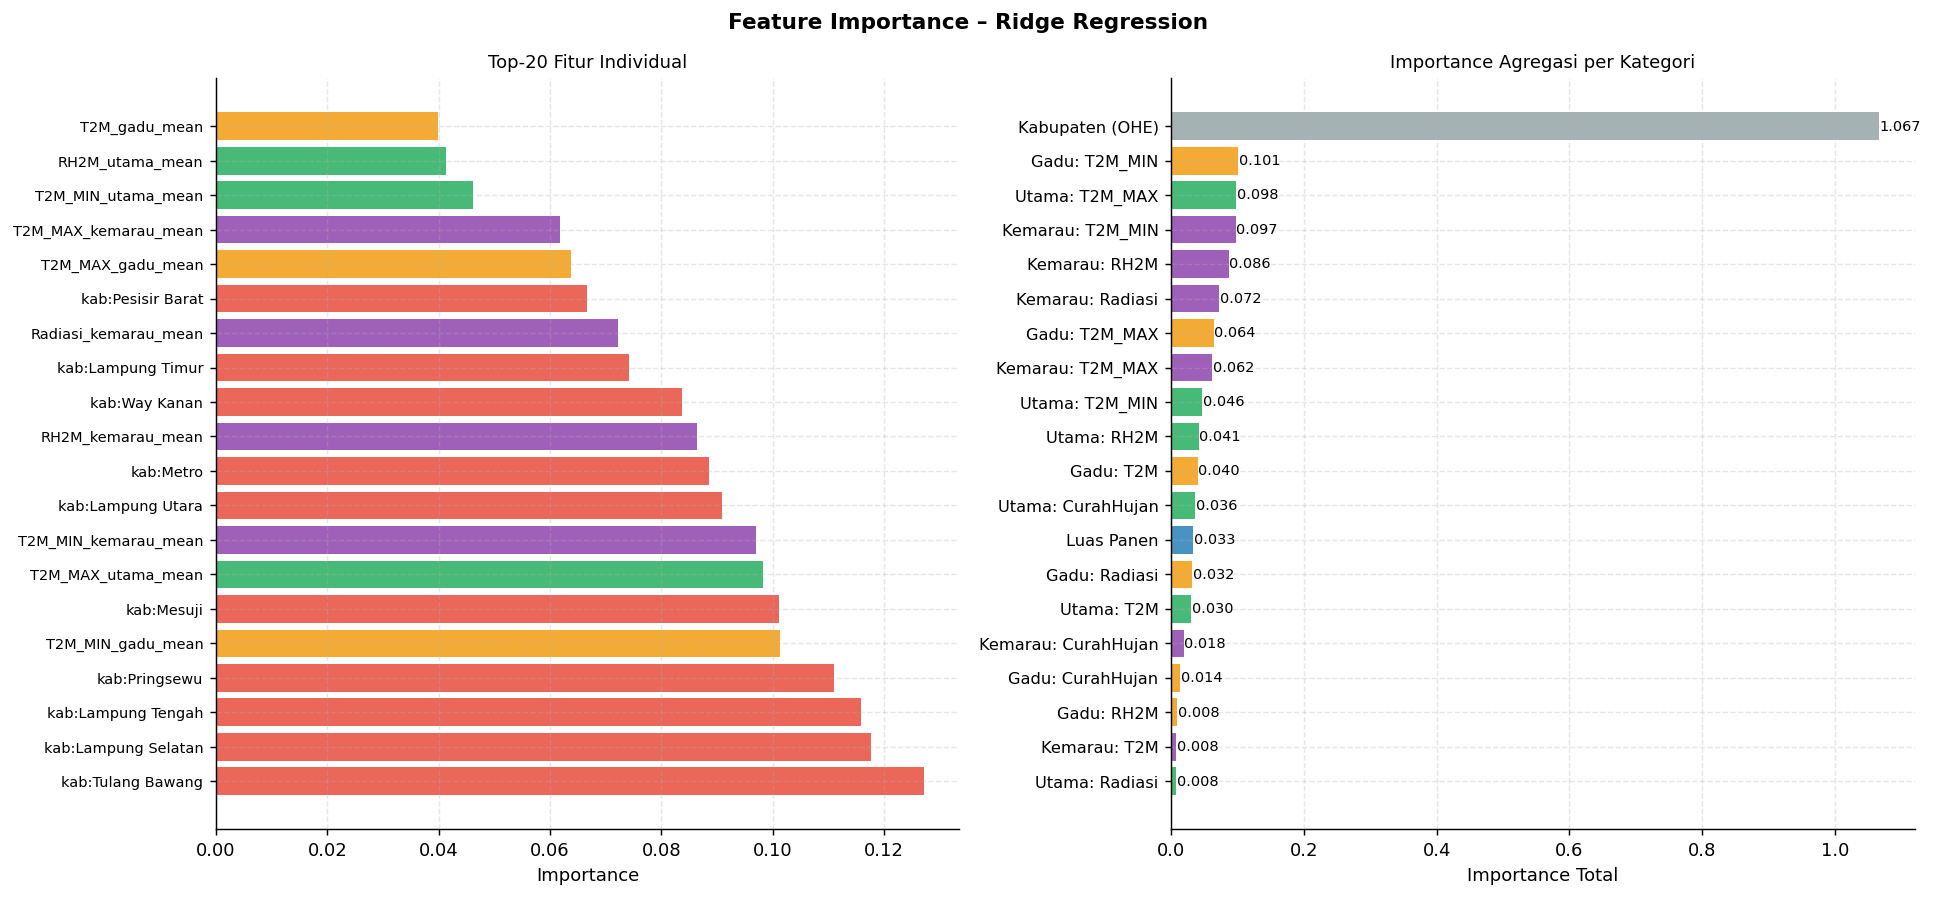

In [25]:
if hasattr(model_final, 'feature_importances_'):
    importances = model_final.feature_importances_
elif hasattr(model_final, 'named_steps'):
    inner       = model_final.named_steps.get('model')
    importances = np.abs(inner.coef_) if hasattr(inner, 'coef_') else None
else:
    importances = None

if importances is not None:
    df_imp = pd.DataFrame({
        'fitur'     : FITUR_MODEL,
        'importance': importances,
    }).sort_values('importance', ascending=False)

    df_imp['kategori'] = df_imp['fitur'].apply(
        lambda c: 'Kabupaten (OHE)' if c.startswith('kabupaten_') else
                  ('Luas Panen'     if c == 'luas_panen_ha' else
                   ('Utama: '   + c.split('_utama')[0].replace('ALLSKY_SFC_SW_DWN', 'Radiasi')
                                                       .replace('PRECTOTCORR', 'CurahHujan')
                    if '_utama_'   in c else
                    ('Gadu: '   + c.split('_gadu')[0].replace('ALLSKY_SFC_SW_DWN', 'Radiasi')
                                                      .replace('PRECTOTCORR', 'CurahHujan')
                    if '_gadu_'    in c else
                    'Kemarau: ' + c.split('_kemarau')[0].replace('ALLSKY_SFC_SW_DWN', 'Radiasi')
                                                         .replace('PRECTOTCORR', 'CurahHujan')
                    )))
    )
    df_agg_imp = df_imp.groupby('kategori')['importance'].sum().sort_values(ascending=True)

    fig, axes = plt.subplots(1, 2, figsize=(15, 7))
    fig.suptitle(f'Feature Importance – {MODEL_TERBAIK}', fontsize=12, fontweight='bold')

    top20       = df_imp.head(20)
    colors_imp  = ['#e74c3c' if 'kabupaten' in c else
                   '#27ae60' if '_utama_'   in c else
                   '#f39c12' if '_gadu_'    in c else
                   '#8e44ad' if '_kemarau_' in c else '#2980b9'
                   for c in top20['fitur']]
    axes[0].barh(range(len(top20)), top20['importance'].values,
                 color=colors_imp, alpha=0.85)
    axes[0].set_yticks(range(len(top20)))
    axes[0].set_yticklabels(
        [c.replace('ALLSKY_SFC_SW_DWN', 'Radiasi')
          .replace('PRECTOTCORR', 'CurahHujan')
          .replace('kabupaten_', 'kab:')
          .replace('luas_panen_ha', 'LuasPanen')
         for c in top20['fitur']],
        fontsize=8
    )
    axes[0].set_title('Top-20 Fitur Individual', fontsize=10)
    axes[0].set_xlabel('Importance')

    colors_cat = ['#95a5a6' if 'Kabupaten' in c else
                  '#27ae60' if 'Utama'     in c else
                  '#f39c12' if 'Gadu'      in c else
                  '#8e44ad' if 'Kemarau'   in c else '#2980b9'
                  for c in df_agg_imp.index]
    axes[1].barh(range(len(df_agg_imp)), df_agg_imp.values,
                 color=colors_cat, alpha=0.85)
    axes[1].set_yticks(range(len(df_agg_imp)))
    axes[1].set_yticklabels(df_agg_imp.index, fontsize=9)
    axes[1].set_title('Importance Agregasi per Kategori', fontsize=10)
    axes[1].set_xlabel('Importance Total')
    for i, v in enumerate(df_agg_imp.values):
        axes[1].text(v + 0.001, i, f'{v:.3f}', va='center', fontsize=8)

    plt.tight_layout()
    plt.savefig('feature_importance.png', bbox_inches='tight', dpi=130)
    plt.show()
else:
    print("Model tidak menyediakan feature importances.")

### 5.4 MAPE per Kabupaten – Data Test 2024

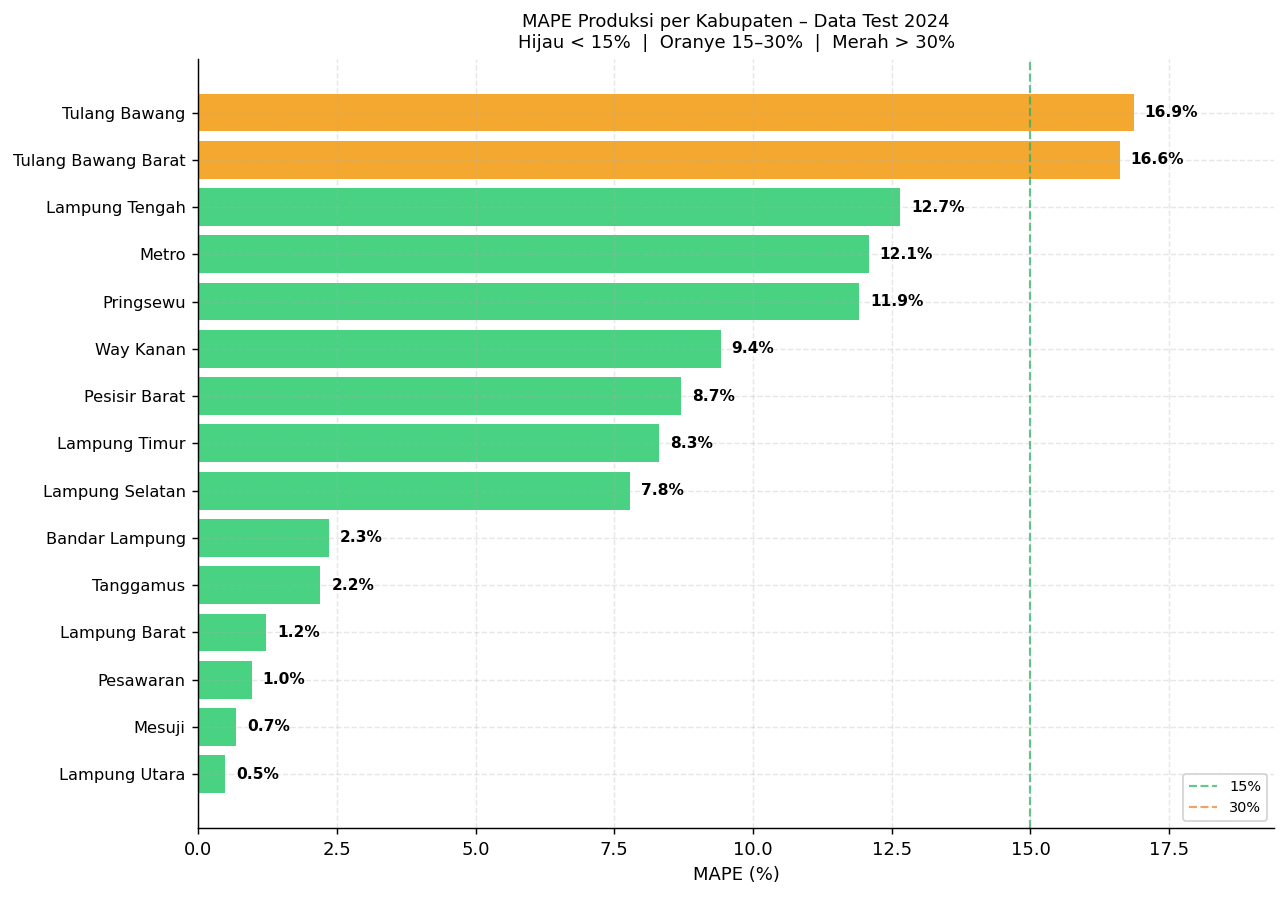

In [26]:
meta_test['mape_produksi'] = (
    np.abs(meta_test['produksi_ton'] - meta_test['produksi_prediksi_ton']) /
    meta_test['produksi_ton'].abs().clip(lower=1e-8) * 100
)
mape_kab = meta_test[['kabupaten', 'mape_produksi']].sort_values('mape_produksi')

fig, ax = plt.subplots(figsize=(10, 7))
colors_mape = ['#2ecc71' if v < 15 else ('#f39c12' if v < 30 else '#e74c3c')
               for v in mape_kab['mape_produksi']]
bars = ax.barh(range(len(mape_kab)), mape_kab['mape_produksi'].values,
               color=colors_mape, alpha=0.88)
ax.set_yticks(range(len(mape_kab)))
ax.set_yticklabels(mape_kab['kabupaten'].values, fontsize=9)
for bar, val in zip(bars, mape_kab['mape_produksi'].values):
    ax.text(val + 0.2, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', ha='left', fontsize=8.5, fontweight='bold')
ax.axvline(15, color='#27ae60', linestyle='--', linewidth=1.2, alpha=0.7, label='15%')
ax.axvline(30, color='#e67e22', linestyle='--', linewidth=1.2, alpha=0.7, label='30%')
ax.set_xlabel('MAPE (%)')
ax.set_title(f'MAPE Produksi per Kabupaten – Data Test 2024\n'
             f'Hijau < 15%  |  Oranye 15–30%  |  Merah > 30%', fontsize=10)
ax.set_xlim(0, mape_kab['mape_produksi'].max() * 1.15)
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('mape_per_kabupaten.png', bbox_inches='tight', dpi=130)
plt.show()

### 5.5 Ringkasan Akhir

In [27]:
zona_hijau  = (mape_kab['mape_produksi'] < 15).sum()
zona_oranye = ((mape_kab['mape_produksi'] >= 15) & (mape_kab['mape_produksi'] < 30)).sum()
zona_merah  = (mape_kab['mape_produksi'] >= 30).sum()

# Parameter model terbaik
if hasattr(model_final, 'get_params'):
    params_final = {k: v for k, v in model_final.get_params().items()
                    if k in ('n_estimators', 'max_depth', 'learning_rate',
                              'subsample', 'min_samples_leaf', 'alpha', 'max_features')}
else:
    params_final = {}

sep = '=' * 65
print(sep)
print("RINGKASAN AKHIR – PREDIKSI PRODUKTIVITAS & PRODUKSI PADI")
print("Provinsi Lampung | Machine Learning Berbasis Musim Tanam")
print(sep)
print(f"  Tanggal generate  : {datetime.date.today()}")
print(f"  Cakupan data      : 15 kabupaten, 2019–2024 (90 sampel)")
print()
print("  Desain Fitur:")
print(f"    Target           : produktivitas_ton_per_ha")
print(f"    Fitur cuaca      : {len(KOLOM_CUACA)} (3 musim × 6 parameter)")
print(f"    Fitur lain       : luas_panen_ha, kabupaten (OHE × {len(KOLOM_KAB_OHE)})")
print(f"    Total fitur      : {len(FITUR_MODEL)}")
print()
print("  Desain Musim Tanam:")
for nm, info in MUSIM.items():
    print(f"    {info['label']}: {info['keterangan']}")
print()
print("  Metode Evaluasi    : Walk-Forward Validation (5 fold, 2020–2024)")
print()
print("  Perbandingan Model (WFV – MAPE rata-rata):")
for name in SEMUA_MODEL:
    h   = WFV_HASIL[name]
    tag = ' ← TERBAIK ML' if name == MODEL_TERBAIK else (
          ' ← BASELINE'   if name.startswith('Naive') else '')
    print(f"    {name:<22}: MAPE {np.mean(h['mape']):.2f}% "
          f"±{np.std(h['mape']):.2f}%  R² {np.mean(h['r2']):.3f}{tag}")
print()
print(f"  Model Terbaik      : {MODEL_TERBAIK}")
print(f"  Parameter          : {params_final}")
print()
print("  Performa Final (Train 2019–2023 / Test 2024):")
print(f"    Produktivitas : RMSE={m_prodvt_ml['RMSE']:.4f} t/ha | "
      f"MAE={m_prodvt_ml['MAE']:.4f} | R²={m_prodvt_ml['R2']:.4f} | "
      f"MAPE={m_prodvt_ml['MAPE']:.2f}%")
print(f"    Naive Kab Mean: RMSE={m_prodvt_nk['RMSE']:.4f} t/ha | "
      f"MAE={m_prodvt_nk['MAE']:.4f} | R²={m_prodvt_nk['R2']:.4f} | "
      f"MAPE={m_prodvt_nk['MAPE']:.2f}%")
print(f"    Produksi (turunan): RMSE={rmse_prod/1e3:.1f} ribu ton | "
      f"R²={r2_prod:.4f}* | MAPE={mape_prod:.2f}%")
print(f"    * R² produksi dipengaruhi variansi luas panen, bukan akurasi model")
print()
print(f"  Distribusi MAPE per Kabupaten (Test 2024):")
print(f"    Akurat   (< 15%) : {zona_hijau:>2} kabupaten")
print(f"    Moderat (15–30%) : {zona_oranye:>2} kabupaten")
print(f"    Lemah   (> 30%)  : {zona_merah:>2} kabupaten")
print(sep)

RINGKASAN AKHIR – PREDIKSI PRODUKTIVITAS & PRODUKSI PADI
Provinsi Lampung | Machine Learning Berbasis Musim Tanam
  Tanggal generate  : 2026-05-10
  Cakupan data      : 15 kabupaten, 2019–2024 (90 sampel)

  Desain Fitur:
    Target           : produktivitas_ton_per_ha
    Fitur cuaca      : 18 (3 musim × 6 parameter)
    Fitur lain       : luas_panen_ha, kabupaten (OHE × 14)
    Total fitur      : 33

  Desain Musim Tanam:
    Musim Tanam Utama (Panen Raya): Nov T-1, Des T-1, Jan T, Feb T, Mar T
    Musim Tanam Gadu (Panen Gadu): Apr T, Mei T, Jun T, Jul T
    Musim Tanam Kemarau (Panen Kecil): Agu T, Sep T, Okt T

  Metode Evaluasi    : Walk-Forward Validation (5 fold, 2020–2024)

  Perbandingan Model (WFV – MAPE rata-rata):
    Ridge Regression      : MAPE 8.14% ±2.59%  R² 0.118 ← TERBAIK ML
    Random Forest         : MAPE 8.17% ±0.43%  R² 0.019
    Gradient Boosting     : MAPE 8.54% ±1.99%  R² 0.019
    Naive Mean            : MAPE 9.26% ±0.80%  R² -0.194 ← BASELINE
    Naive Kab 